In [ ]:
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

#pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)


#df = pd.read_csv("../../image_collection1.csv")
df = pd.read_csv('image_collection.csv')
df['date-obs'] = pd.to_datetime(df['date-obs'])
df["night"] = df["night"].astype(str)
df.loc[df["night"] == "20240827b", "night"] = "20240827"
df.loc[df["night"] == "20240209", "night"] = "20240902"
df.loc[
    (df["night"] == "20240915") &
    (df["date-obs"] == pd.Timestamp('2024-09-21T00:00:00')),
    "night"
] = pd.NA
mask = (df["imagetyp"]=="object") & (df["file"].str.contains("flat")) & (df["exptime"]<30)
df.loc[mask, "imagetyp"] = "flat"
df.loc[mask, "object"] = pd.NA

#"20240314" → ahi hay unbias del 24/03/07
df["wheel"] = "a"
df["wheel"] = df["wheel"].astype("object")
mask = df["filter"].notna()  
df.loc[mask, "wheel"] = df.loc[mask, "filter"]
mask = df["filter01"].notna()  
df.loc[mask, "wheel"] = df.loc[mask, "filter01"]

df["wheel_aux"] = "a"
df["wheel_aux"] = df["wheel_aux"].astype("object")
mask = df["filter1"].notna()  
df.loc[mask, "wheel_aux"] = df.loc[mask, "filter1"]
mask = df["filter02"].notna()  
df.loc[mask, "wheel_aux"] = df.loc[mask, "filter02"]



coords = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
mask_nan = np.isnan(coords.ra.deg) | np.isnan(coords.dec.deg)
df = df.loc[~mask_nan].copy()
#print("Filas con NaN reales:", mask_nan.sum())
#df_bad = df.loc[mask_nan, ["ra2000", "dec2000", "object", "imagetyp", "night", "ra", "dec", "wheel"]]
coords_clean = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
print("NaNs restantes en RA:", np.isnan(coords_clean.ra.deg).sum())
print("NaNs restantes en DEC:", np.isnan(coords_clean.dec.deg).sum())

import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ==============================
# RUTA AL CATÁLOGO DE OBJETOS
# ==============================
CATALOG_PATH = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/objetos.csv"

# ==============================
# CARGAR CATÁLOGO
# ==============================
cat = pd.read_csv(CATALOG_PATH)

cat_coords = SkyCoord(
    ra=cat["ra_deg"].values * u.deg,
    dec=cat["dec_deg"].values * u.deg
)

# ==============================
# DATAFRAME DE IMÁGENES
# ==============================
# df debe existir con columnas: ra2000, dec2000, object
img_coords = SkyCoord(
    df["ra2000"].astype(str).values,
    df["dec2000"].astype(str).values,
    unit=(u.hourangle, u.deg)
)

# ==============================
# CROSS-MATCH
# ==============================
idx, sep2d, _ = img_coords.match_to_catalog_sky(cat_coords)

df["orig_obj"] = df["object"]  # Guardar nombre original siempre
df["nearest_obj"] = cat.loc[idx, "objeto"].values
df["sep_arcsec"] = sep2d.arcsec

# ==============================
# COMPARACIÓN DE NOMBRES
# ==============================
df["name_match"] = df["object"] == df["nearest_obj"]

# ==============================
# UMBRAL DE DISTANCIA ANGULAR
# ==============================
MAX_SEP = 9.6*60*4  # arcsec  = radio de fov en arcmin * 60 * 2.5 (factor por mal setpoint)
df["close_match"] = df["sep_arcsec"] < MAX_SEP

# ==============================
# CASOS CON NOMBRE INCORRECTO
# ==============================
wrong_name = df[(df["close_match"]) & (~df["name_match"]) & (df["imagetyp"] == "object")]
print("\nWRONG NAME + MATCH OBJECT:")
print(f"Total: {len(wrong_name)}")

# ==============================
# CASOS SIN OBJETO CERCANO
# ==============================
no_object = df[~df["close_match"] & (df["imagetyp"] == "object")]
print("\nNO MATCH OBJECT")
print(f"Total: {len(no_object)}")

# ==============================
# DOBLE CHECK ANTES DE CORREGIR
# ==============================

approve_changes = True
if len(wrong_name) > 0:
    # Agrupar por nombre original y nearest_obj
    summary = (wrong_name
               .groupby(["object", "nearest_obj"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))

    print("\nResumen de cambios propuestos (agrupado por object -> nearest_obj):")
    print(summary.head())  # mostrar solo los 20 más frecuentes

    #approve_changes = input("\n¿Desea reemplazar los nombres incorrectos por 'nearest_obj'? (s/n): ").lower()
    if approve_changes == True:
        mask_fix = (df["imagetyp"] == "object") & (df["close_match"]) & (~df["name_match"])
        df.loc[mask_fix, "object"] = df.loc[mask_fix, "nearest_obj"]
        print(f"\n✔️ Se corrigieron {mask_fix.sum()} nombres automáticamente")
    else: #if isinstance(approve, int):
        #print(summary.loc[approve])
        #correct = input("Input correct object name: ")
        print("\n❌ No se hicieron cambios. Revise los nombres manualmente.")

mark_wrong = True
if len(no_object) > 0:
    print("\n❗ Atención: hay imágenes sin un objeto cercano en el catálogo.")
    summary_noobj = (no_object
               .groupby(["object", "nearest_obj"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))
    print(no_object[["object", "ra2000", "dec2000", "sep_arcsec"]].head())
    if mark_wrong:
        df.loc[no_object.index, "object"] = "NO_OBJECT"





/tmp/ipykernel_61642/2329480314.py:11: DtypeWarning: Columns (17,20,21,29,31,41,43,53,67,80,93,97) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('image_collection.csv')


NaNs restantes en RA: 0
NaNs restantes en DEC: 0



WRONG NAME + MATCH OBJECT:
Total: 4970

NO MATCH OBJECT
Total: 435

Resumen de cambios propuestos (agrupado por object -> nearest_obj):
           object         nearest_obj  count
60  OGLE-BLG-0669  OGLE-2024-BLG-0669    575
59  OGLE-BLG-0605  OGLE-2024-BLG-0605    503
23      Gaia24bsi           Gaia24bsj    242
57  OGLE-BLG-0592  OGLE-2024-BLG-0592    234
24     Gaia24bsi_           Gaia24bsi    197

✔️ Se corrigieron 4970 nombres automáticamente

❗ Atención: hay imágenes sin un objeto cercano en el catálogo.
        object      ra2000      dec2000     sep_arcsec
707    NGC2442  07:36:46.7  -69:33:23.1   38879.521773
708    NGC2442  07:36:55.9  -69:29:57.5   38987.353990
709    NGC2442  07:36:55.8  -69:29:57.5   38986.853369
710    NGC2442  07:36:55.9  -69:29:57.5   38987.353990
755  SetPoint2  09:12:11.9  -27:14:51.3  190638.495691


In [58]:
#df = pd.read_csv('data1/image_collection.csv')
df[["imagetyp", "object"]].groupby(["imagetyp"]).count()
#df.imagetyp.value_counts()

,object
imagetyp,
dark,0
flat,0
object,20167
zero,0


In [59]:

from astropy.io import fits

filename = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250605/bias0019.fit"

with fits.open(filename) as hdul:
    header = hdul[0].header   # Header del HDU primario
    data = hdul[0].data       # Datos de la imagen (array)
for key in header:
    print(f"{key}   {header[key]}")


SIMPLE   True
BITPIX   16
NAXIS   2
NAXIS1   1024
NAXIS2   1024
BSCALE   1.0
BZERO   32768.0
CCDSIZE   [1:1024,1:1024]
CCDSUM   1 1
PIXSIZE1   24.0
PIXSIZE2   24.0
ADCRATE   
GAIN   2.2
RDNOISE   15
CAMTEM   -20.0
EXPTIME   0.0
DATE   2025-06-06T07:08:20
OBSERVAT   CASLEO
TELESCOP   HSH
DATE-OBS   2025-06-06T10:08:32.986
TIME-OBS   10:08:13.509
UT   10:08:33.5
ST   22:31:23.1
HA   -00:01:12.0
RA   22:32:35.2
DEC   -31:47:13.3
EQUINOX   2025.4
MJD-OBS   60832.422604
ZD   0.3
AIRMASS   1.0
RA2000   22:31:09.1
DEC2000   -31:55:05.7
DOME-AZ   341.7
IMAGETYP   zero
INSTRUME   Direct CCD
INSTRMOD   
OBSERVER   Izraelevitch
OPTELE   
COMMENT   = ' '
PROG-ID   HSH-2025A-05
DETECTOR   STL-1001E
PIXSCALE   0.53
FILTER01   (1) Free
FILTER02   (2) Blind
FILENAME   /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250605/bias0019.fit
FILTERS   e
OBJECT   bias
OBJ_STAT   NOT_CHECKED


SIMPLE  =                    T                                                  
BITPIX  =                   16                                                  
NAXIS   =                    2                                                  
NAXIS1  =                 1024   / number of columns                            
NAXIS2  =                 1024   / number of rows                               
BSCALE  =                  1.0   / PhysValue = BZERO + BSCALE * ArrayValue      
BZERO   =              32768.0   / PhysValue = BZERO + BSCALE * ArrayValue      
CCDSIZE = '[1:1024,1:1024] '     / CCD size                                     
CCDSUM  = '1 1 '                 / CCD binning factors                          
PIXSIZE1=                 24.0   / pixel size for axis 1 (um)                   
PIXSIZE2=                 24.0   / pixel size for axis 2 (um)                   
GAIN    =                  2.2   / CCD gain (e-/ADU)                            
RDNOISE =                 15.0   / Readout noise (e- RMS)                       
CAMTEM  =                -32.0   / camera temperature (degrees Celsius)         
EXPTIME =                 0.20   / exposure time - seconds                      
OBSERVAT= 'CASLEO '              / observatory of observation                   
TELESCOP= 'HSH '                 / telescope of observation                     
DATE-OBS= '2024-07-04 '          / date of observation (yyyy-mm-dd)             
TIME-OBS= '21:47:08.200 '        / time at the start of the observation         
UT      = '21:47:07.3 '          / universal time                               
ST      = '12:03:33.4 '          / sidereal time                                
HA      = '+01:10:04.3 '         / hour angle                                   
RA      = '10:53:29.0 '          / right ascension                              
DEC     = '-31:47:04.3 '         / declination                                  
EQUINOX =               2024.5   / epoch of ra y dec                            
MJD-OBS =         60495.907720   / modified Julian date of the observation      
ZD      =                 14.9   / zenith distance                              
AIRMASS =                 1.03   / airmass                                      
RA2000  = '10:52:19.5 '          / right ascension J2000                        
DEC2000 = '-31:39:14.0 '         / declination J2000                            
TRK_FRQ =                59.99   / tracking frequency (Hz)                      
HA_PRLD =                 495.   / HA preload current (mA)                      
DEC_PRLD=                 699.   / DEC preload current (mA)                     
IMAGETYP= 'flat '                / object, dark, zero, etc.                     
INSTRUME= 'Direct CCD '                                                         
OBSERVER= 'Varela-Mast '                                                        
COMMENT = ' '                                                                   
PROG-ID = 'HSH-2024A-03 '                                                       
FILTER  = '(3) V '               / Filter wheel                                 
FILTER1 = '(6) Free '            / Auxiliar Filter wheel  

In [247]:
sky_cols = ['ra2000', 'dec2000', 'ra', 'dec']


detector_cols = [
    "gain", "rdnoise", "camtem", "detector", "adcrate"
]

datetime_cols = [
    "date", "date-obs", "time-obs", "ut", "mjd-obs", "st"
]

pointing_cols = [
    "ra", "dec", "ra2000", "dec2000", "equinox",
    "ha", "zd", "airmass"
]

telescope_cols = [
    "observat", "telescop", "dome-az", "optele"
]

obs_set_cols = [ "filter", "filter1", "filter01", "filter02",
    "imagetyp", "exptime", 
]
#filter_cols = [ "filter", "filter1", "filter01", "filter02"]
filter_cols = ["wheel", "wheel_aux"]

for col in obs_set_cols:
    print(df[col].value_counts())

filter
(5) I       12148
(3) V        8337
(1) Free      116
(4) R         116
(2) B          99
Name: count, dtype: int64
filter1
(6) Free       20804
(4) H-Alpha       10
(5) ND213B         2
Name: count, dtype: int64
filter01
(5) I       6609
(3) V       5446
(1) Free     180
(2) B         91
(4) R         61
Name: count, dtype: int64
filter02
(6) Free       11299
(2) Blind        815
(3) Blind        192
(5) ND213B        41
(4) H-Alpha       20
(1) U             20
Name: count, dtype: int64
imagetyp
object    20167
flat       6839
zero       3441
dark       2756
Name: count, dtype: int64
exptime
60.00     6922
90.00     5883
0.00      3444
120.00    3042
300.00    2563
          ... 
0.23         1
40.00        1
3.80         1
61.00        1
11.00        1
Name: count, Length: 112, dtype: int64


In [248]:
df["object"].value_counts()

object
OGLE-2025-BLG-0675    3208
OGLE-2024-BLG-0592    2561
OGLE-2024-BLG-0674    2411
Gaia24bsi             1645
Gaia24bsj             1420
OGLE-2024-DG-0016     1099
OGLE-2024-BLG-0669    1036
OGLE-2024-GD-0006     1018
OGLE-2024-BLG-0605     982
OGLE-2025-GD-0001      748
OGLE-2024-BLG-0034     593
ASASSN-24fs            547
NO_OBJECT              435
OGLE-2023-GD-0011      389
OGLE-2025-BLG-0397     306
Gaia24ddl              256
OGLE-2025-BLG-0451     203
OGLE-2025-BLG-0245     179
OGLE-2025-BLG-0715     172
OGLE-2024-GD-0014      172
Gaia23cnu              168
OGLE-2024-BLG-0010     162
OGLE-2025-BLG-0681     155
OGLE-2024-BLG-0002      89
OGLE-2025-BLG-1480      77
OGLE-2024-BLG-0009      59
OGLE-2024-GD-0001       42
Gaia23dpn               28
OGLE-2025-GD-0006        6
OGLE-2023-BLG-0723       1
Name: count, dtype: int64

In [100]:
for name in df[df["object"] =="NO_OBJECT"].orig_obj.value_counts().keys():
    print(name)

TOI3071
Gaia24bsj
OGLE-2024-GD-0006
Test
foco
setpoint
OGLE-2024-BLG-0592
M83
OGLE-2024-DG-0016
OGLE2024DG0016
set
NGC2442
Set Point
OGLE-2024-DG-006
OGLE-2025-BLG-0675
Altair
RXJ1131
focus
Wasp15
wasp15
BD -17 3129
OGLE-2024-GD-006
ser
NGC3338
galaxia1
SetPoint2
Gaia22ccd
NGC2217
galaxia
set point
NGC4945
OGLE
setup
SetPoint
OGLE2-024-BLG-0592
?GLE-2024-BLG-0592
OGLE2024BLG0669
SMC
Gaia24bsj_
NGC0092
setpoint1
Setpoint
NGC7172
WD0830-535


In [244]:
obj = "OGLE-2024-GD-006"
df[(df["orig_obj"]==obj)&(df["object"]=="NO_OBJECT")][["object","sep_arcsec", "date-obs","time-obs", "observer", "ra2000", "dec2000", "exptime"]]

,object,sep_arcsec,date-obs,time-obs,observer,ra2000,dec2000,exptime
4369,NO_OBJECT,114693.154856,2024-07-01,22:49:59.116,Makler,12:53:36.1,-31:39:12.4,0
4370,NO_OBJECT,114646.612796,2024-07-01,22:50:07.037,Makler,12:53:44.1,-31:39:12.5,0


In [ ]:
df[df["object"]=="NO_OBJECT"]["observer"].value_counts() 


observer
Buccino-Mast-Varela           161
Makler                        114
Mast                           32
Nowogrodzki                    29
Buccino                        15
Varela                         14
Makler/Nowo                     8
Nowo                            8
Mast - Buccino                  7
Damian Mast                     7
Buccino-Izraelevich             7
Buccino-Makler                  4
Buccino-Varela                  4
Buccino-Makler-Varela           4
Varela-Mast                     3
Buccino-Nowogrodzki             3
Makler-Buccino                  3
Buccino-Izraelevitch            2
Varela Anibal, Mast Damian      2
Nowogrodzki-Mast                1
Makler-Izraelevitch             1
Martin Makler                   1
Andrea Buccino                  1
Mammana                         1
Norowodski                      1
Makler-Varela                   1
Mast-Makler                     1
Name: count, dtype: int64

In [55]:
import os
import json
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# Ruta de archivos
data_dir = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/microlensing_data"
csv_file = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/objetos.csv"

# Leer csv existente
df_csv = pd.read_csv(csv_file)

# Crear un diccionario para chequear objetos existentes
objetos_existentes = {obj: idx for idx, obj in enumerate(df_csv['objeto'])}

# Recorrer los JSON
for fname in os.listdir(data_dir):
    if fname.endswith(".json"):
        path = os.path.join(data_dir, fname)
        with open(path, "r") as f:
            data = json.load(f)
        
        objeto = fname.split("_")[0]   # ej: OGLE-2025-BLG-1480
        ra_str = data["RA"]
        dec_str = data["Dec"]
        
        # Convertir a grados
        coord = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg))
        ra_deg = coord.ra.deg
        dec_deg = coord.dec.deg
        
        # Si el objeto ya existe, actualizar coordenadas si es más reciente
        if objeto not in objetos_existentes:
            # Agregar objeto nuevo
            df_csv = pd.concat([
                df_csv,
                pd.DataFrame({
                    "objeto": [objeto],
                    "ra_deg": [ra_deg],
                    "dec_deg": [dec_deg],
                    "ra_ecu": [ra_str],
                    "dec_ecu": [dec_str]
                })
            ], ignore_index=True)

# Guardar csv actualizado
df_csv.to_csv(csv_file, index=False)
print("objetos.csv actualizado con todos los targets de microlensing_data")


objetos.csv actualizado con todos los targets de microlensing_data


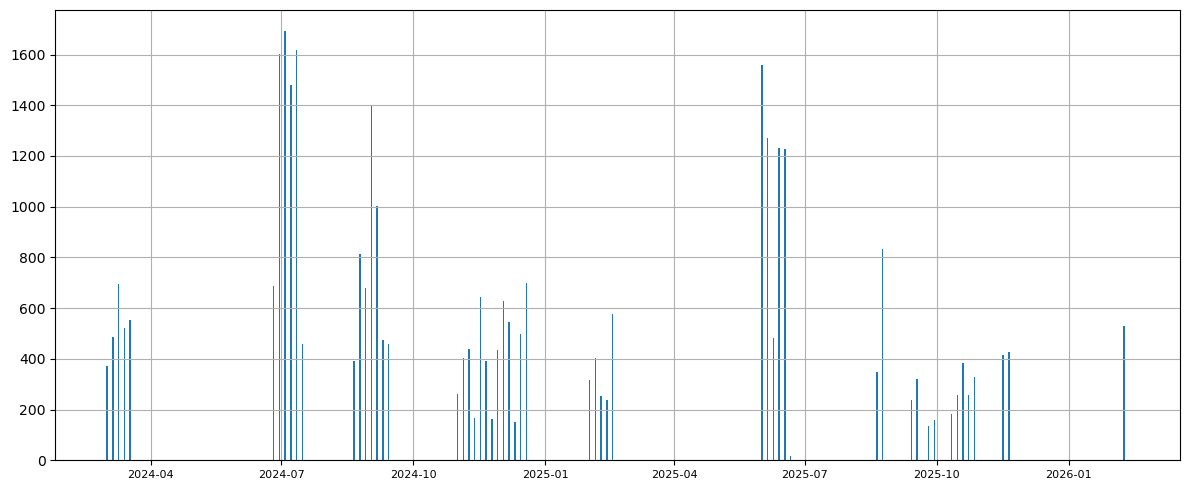

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
plt.figure(figsize=(12,5))
df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")
ax = df["night"].hist(bins=len(df["night"].value_counts().keys()), width=1)
#ax1 = ax.twinx()
#ax1.plot(df["night"], df["airmass"], "rs", markersize=1)

ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()


In [9]:
seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons = seasons_df["season"].value_counts().keys()
season_df = seasons_df[seasons_df["season"]==seasons[0]]

df_objects = df.loc[
    df["night"].isin(seasons_df["date"])
]
df_objects
#df["night"].values[0], seasons_df["date"].values[0]

,equinox,a_1_0,bp_order,a_0_2,latpole,bp_0_1,st,naxis,crpix2,ap_0_0,...,b_0_2,detector,camtem,wheel,wheel_aux,orig_obj,nearest_obj,sep_arcsec,name_match,close_match
358,2024.1,NaN,NaN,NaN,NaN,NaN,05:36:08.7,2,NaN,NaN,...,NaN,NaN,-20.0,(5) I,(6) Free,NaN,Gaia24bsi,143740.858347,False,False
361,2024.1,NaN,NaN,NaN,NaN,NaN,05:37:09.7,2,NaN,NaN,...,NaN,NaN,-20.0,(5) I,(6) Free,NaN,Gaia24bsi,143887.398444,False,False
360,2024.1,NaN,NaN,NaN,NaN,NaN,05:36:32.9,2,NaN,NaN,...,NaN,NaN,-20.0,(5) I,(6) Free,NaN,Gaia24bsi,143798.628035,False,False
359,2024.1,NaN,NaN,NaN,NaN,NaN,05:36:20.7,2,NaN,NaN,...,NaN,NaN,-19.0,(5) I,(6) Free,NaN,Gaia24bsi,143769.593786,False,False
357,2024.1,NaN,NaN,NaN,NaN,NaN,05:35:56.7,2,NaN,NaN,...,NaN,NaN,-19.0,(5) I,(6) Free,NaN,Gaia24bsi,143712.420223,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32551,2025.8,NaN,NaN,NaN,NaN,NaN,21:32:21.5,2,NaN,NaN,...,NaN,STL-1001E,-5.0,(2) B,(2) Blind,NaN,ASASSN-24fs,123421.239994,False,False
32553,2025.8,NaN,NaN,NaN,NaN,NaN,21:32:36.8,2,NaN,NaN,...,NaN,STL-1001E,-5.0,(2) B,(2) Blind,NaN,ASASSN-24fs,123573.646403,False,False
32554,2025.8,NaN,NaN,NaN,NaN,NaN,21:32:45.0,2,NaN,NaN,...,NaN,STL-1001E,-5.0,(2) B,(2) Blind,NaN,ASASSN-24fs,123655.425016,False,False
32546,2025.8,NaN,NaN,NaN,NaN,NaN,05:00:02.5,2,NaN,NaN,...,NaN,STL-1001E,-28.0,(3) V,(6) Free,Gaia24bsj,Gaia24bsj,265.045227,True,False


Plotting season: HSH-2024A-03


/tmp/ipykernel_59583/4290792887.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_59583/4290792887.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


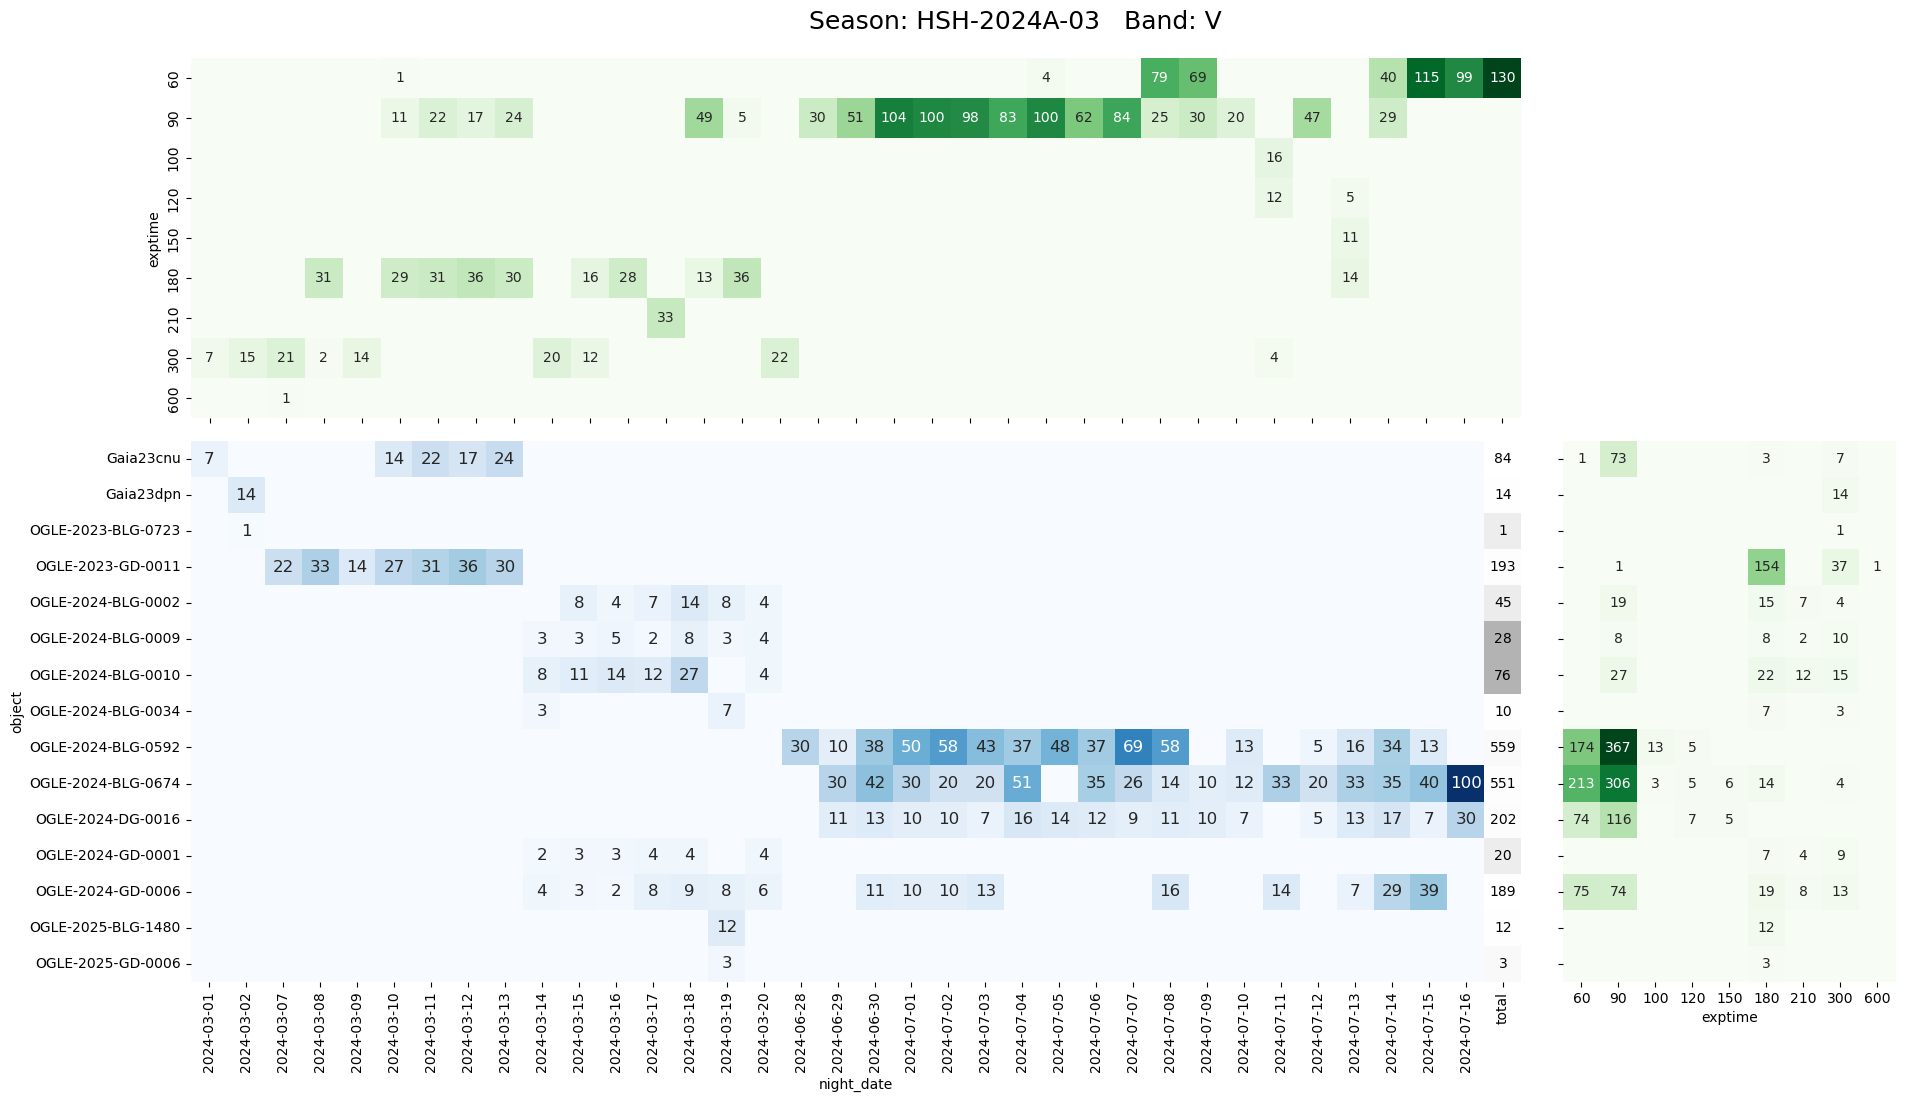

/tmp/ipykernel_59583/4290792887.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_59583/4290792887.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


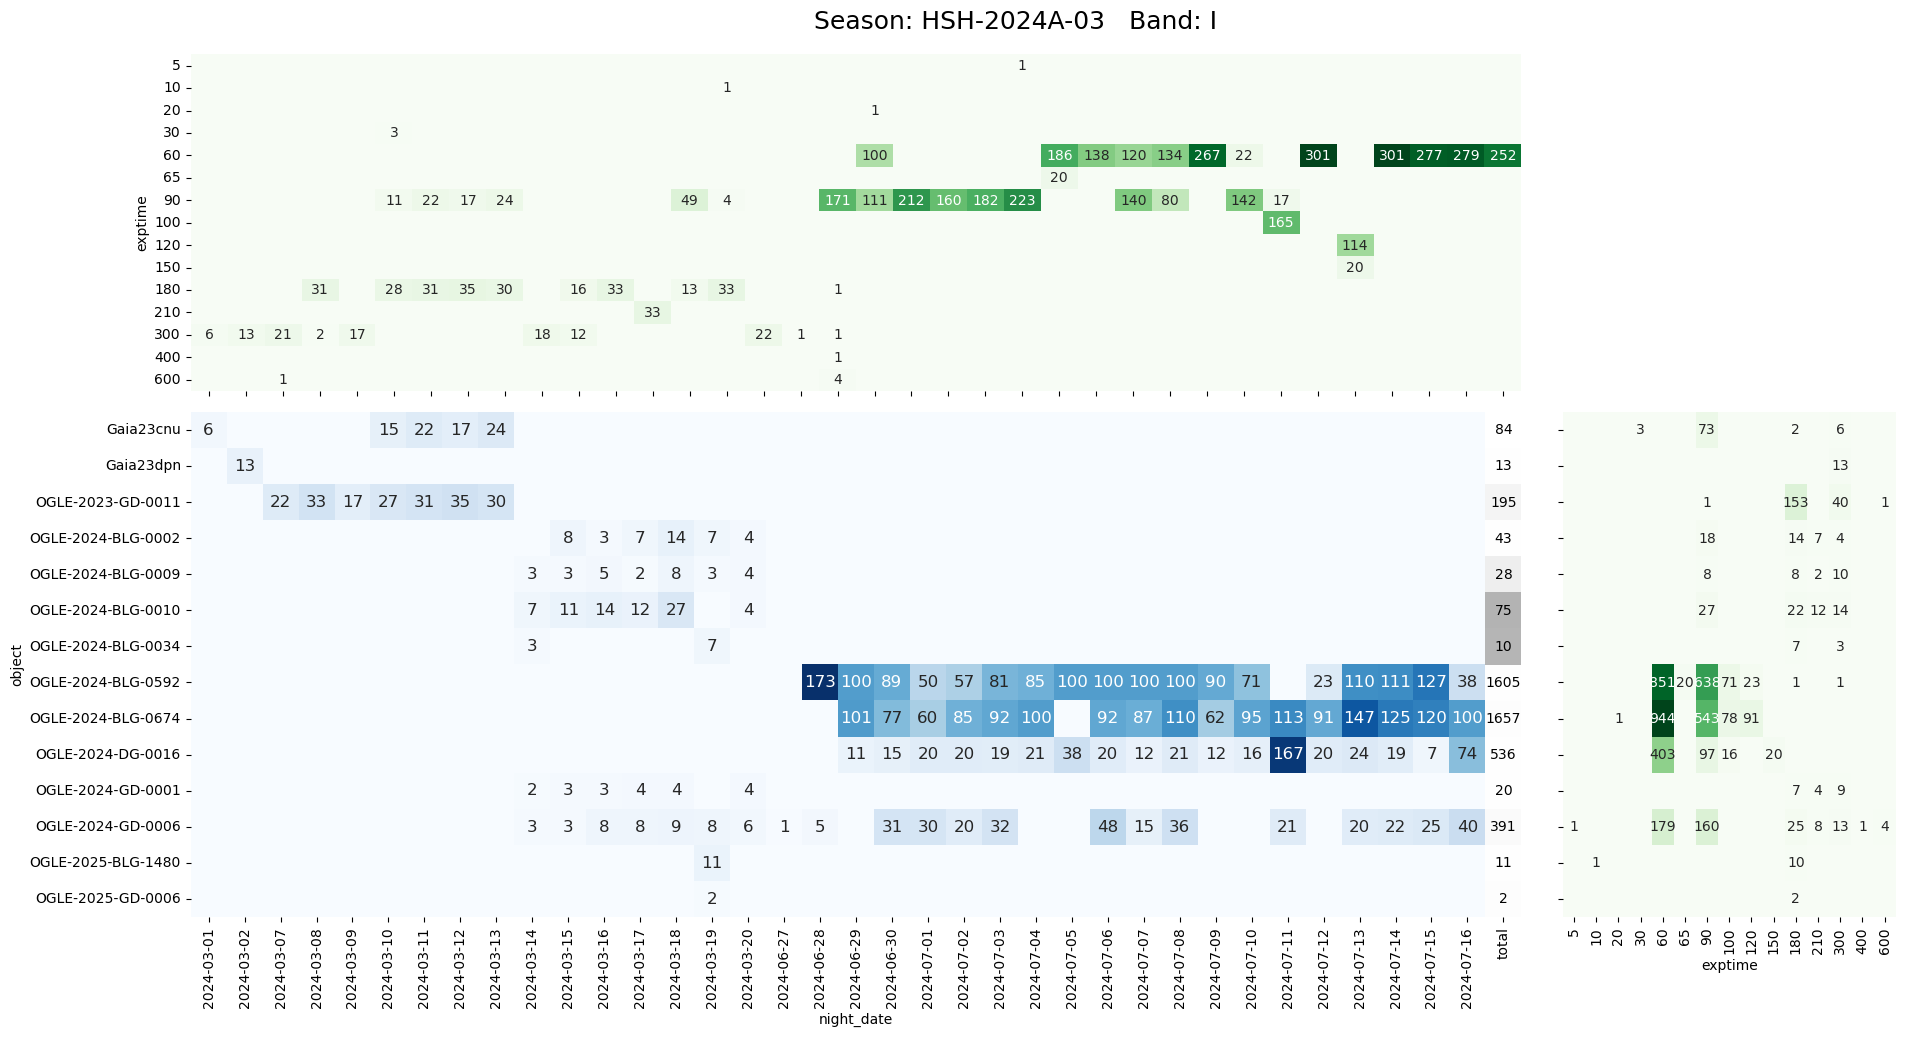

Plotting season: HSH-2024B-05


/tmp/ipykernel_59583/4290792887.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_59583/4290792887.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


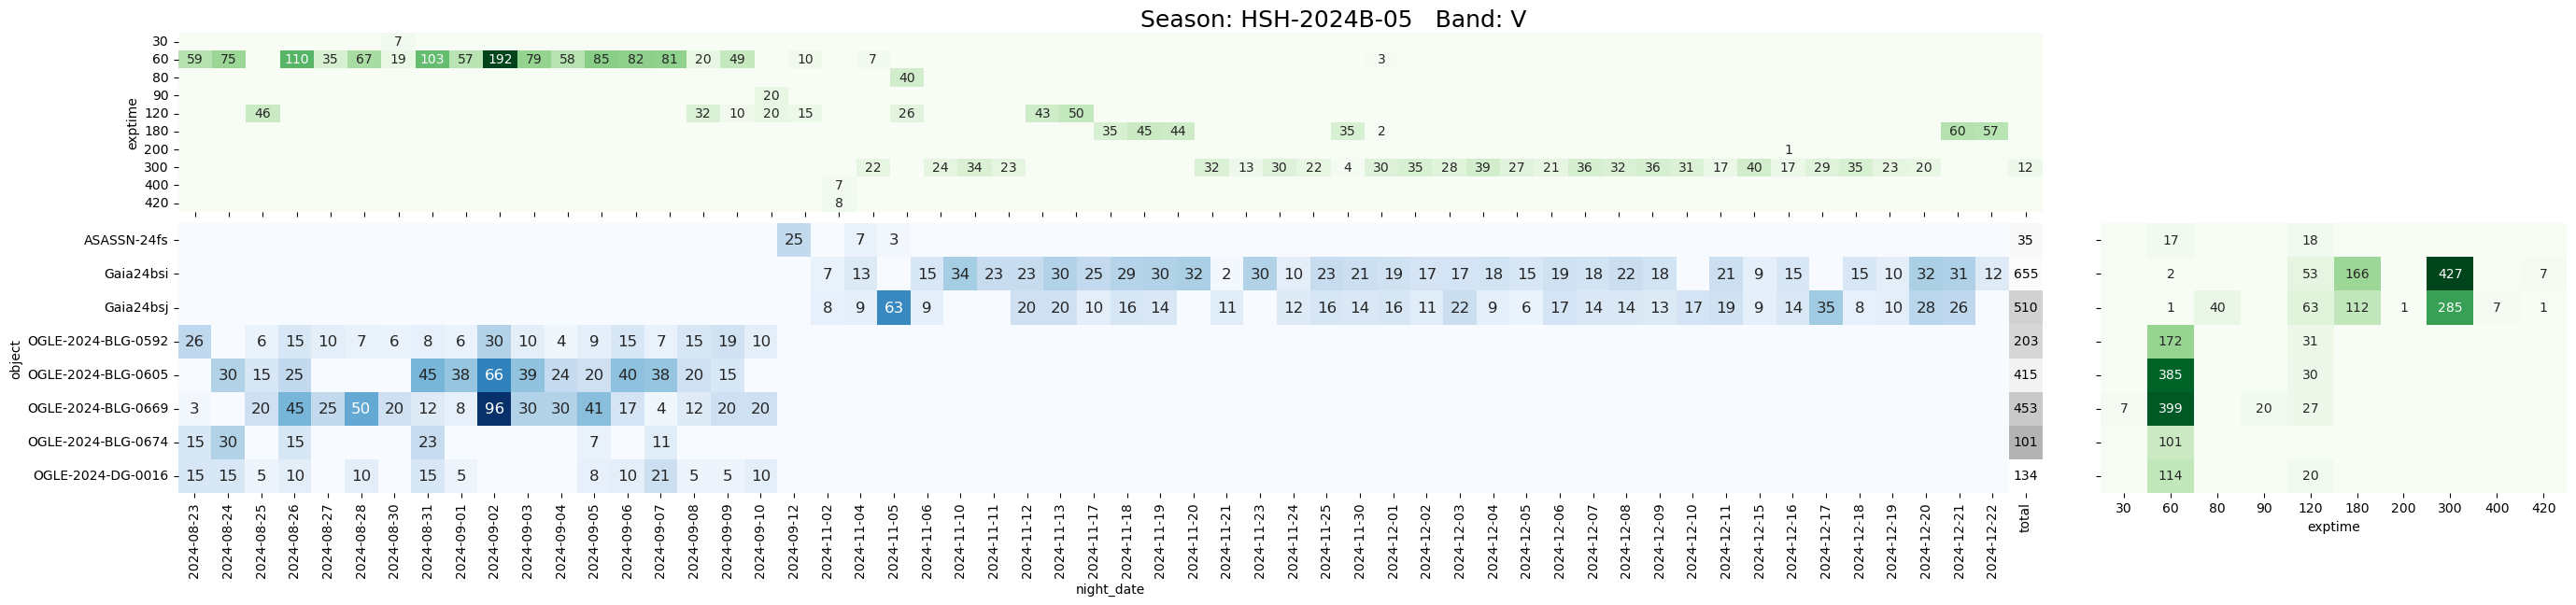

/tmp/ipykernel_59583/4290792887.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_59583/4290792887.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


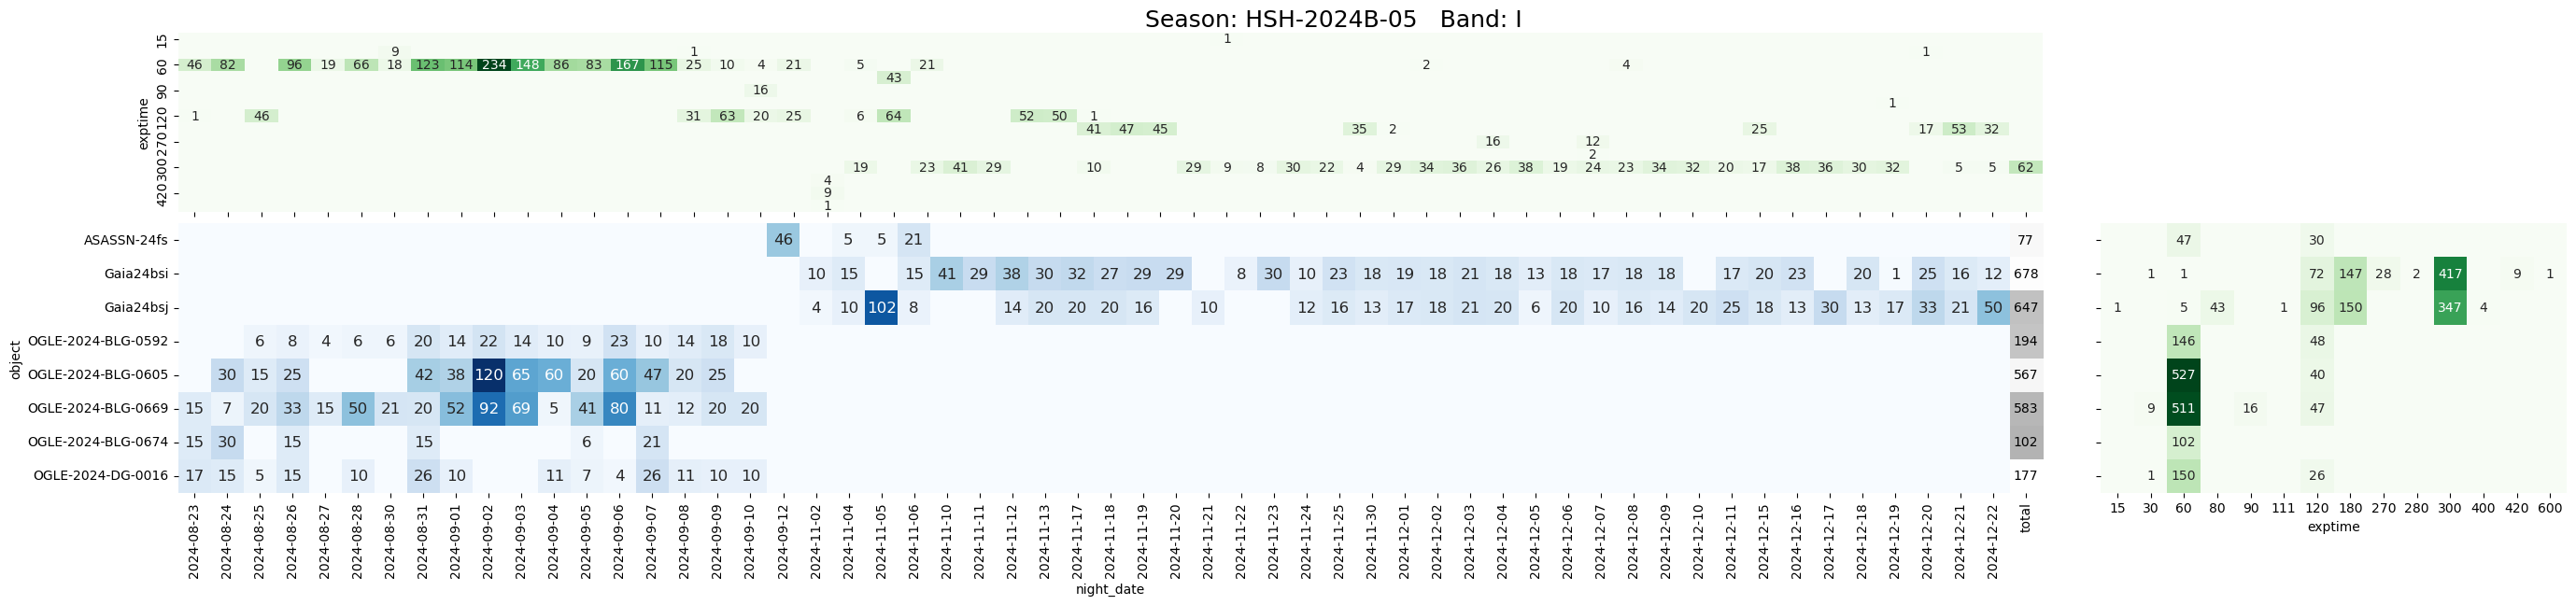

Plotting season: HSH-2025A-05


/tmp/ipykernel_59583/4290792887.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_59583/4290792887.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


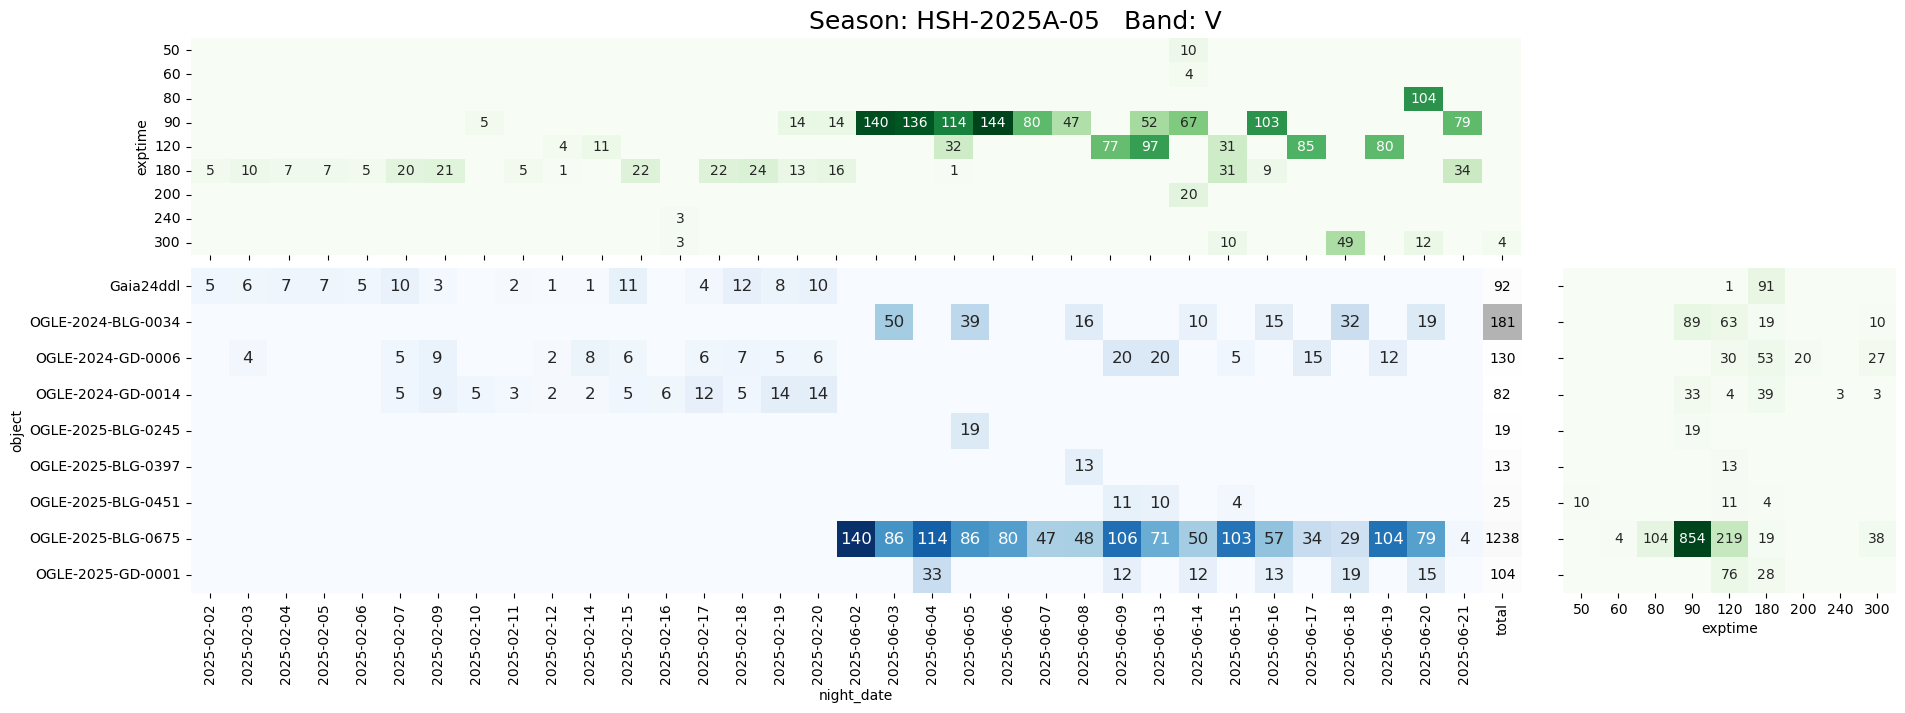

/tmp/ipykernel_59583/4290792887.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_59583/4290792887.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


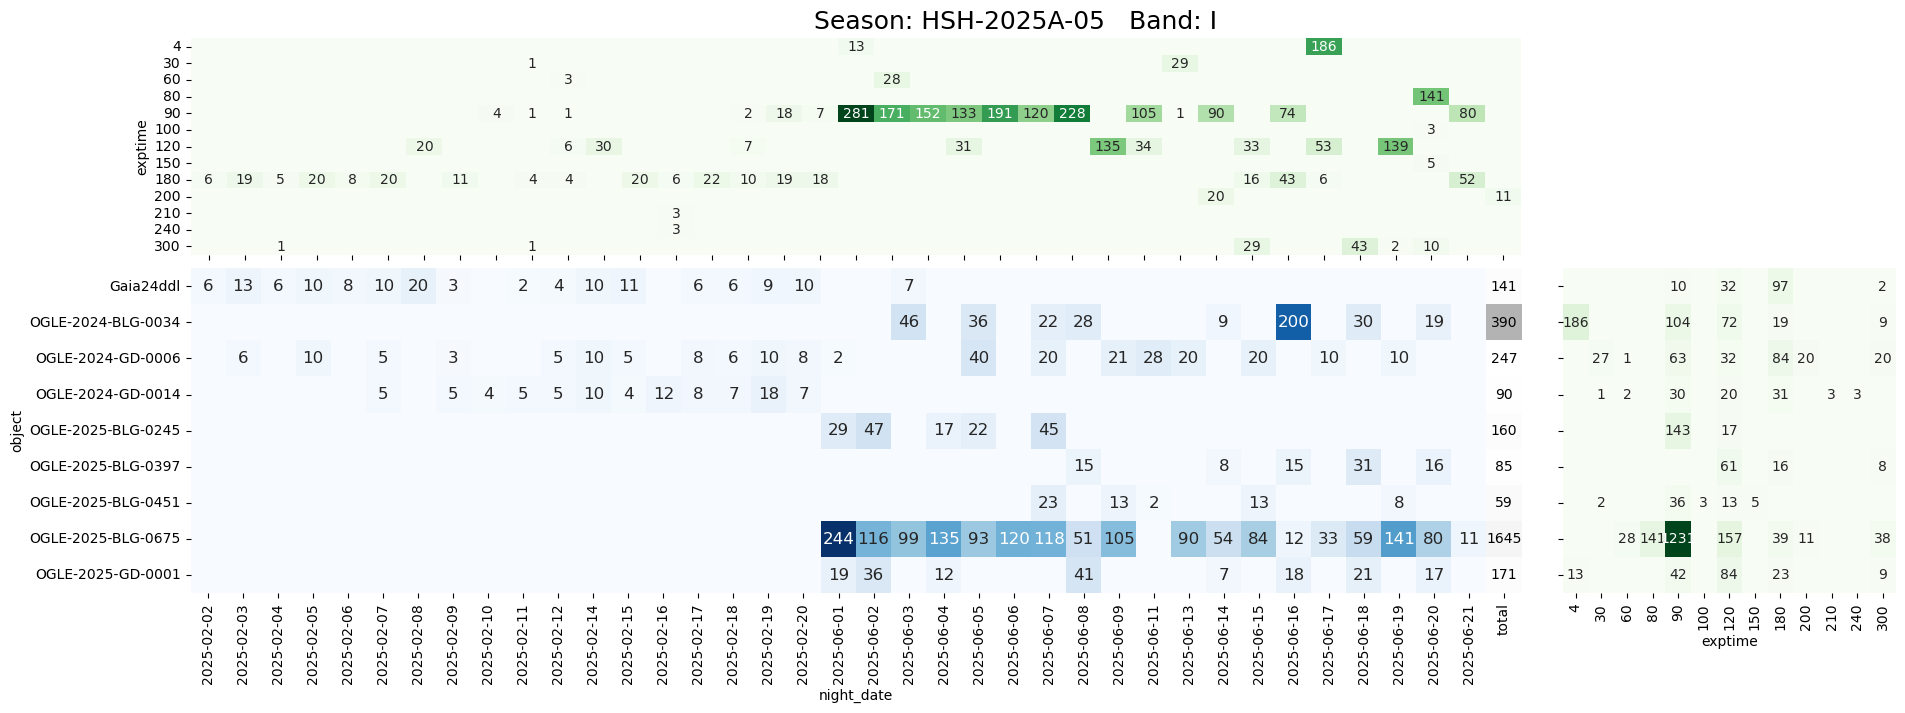

Plotting season: HSH-2025B-03


/tmp/ipykernel_59583/4290792887.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_59583/4290792887.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


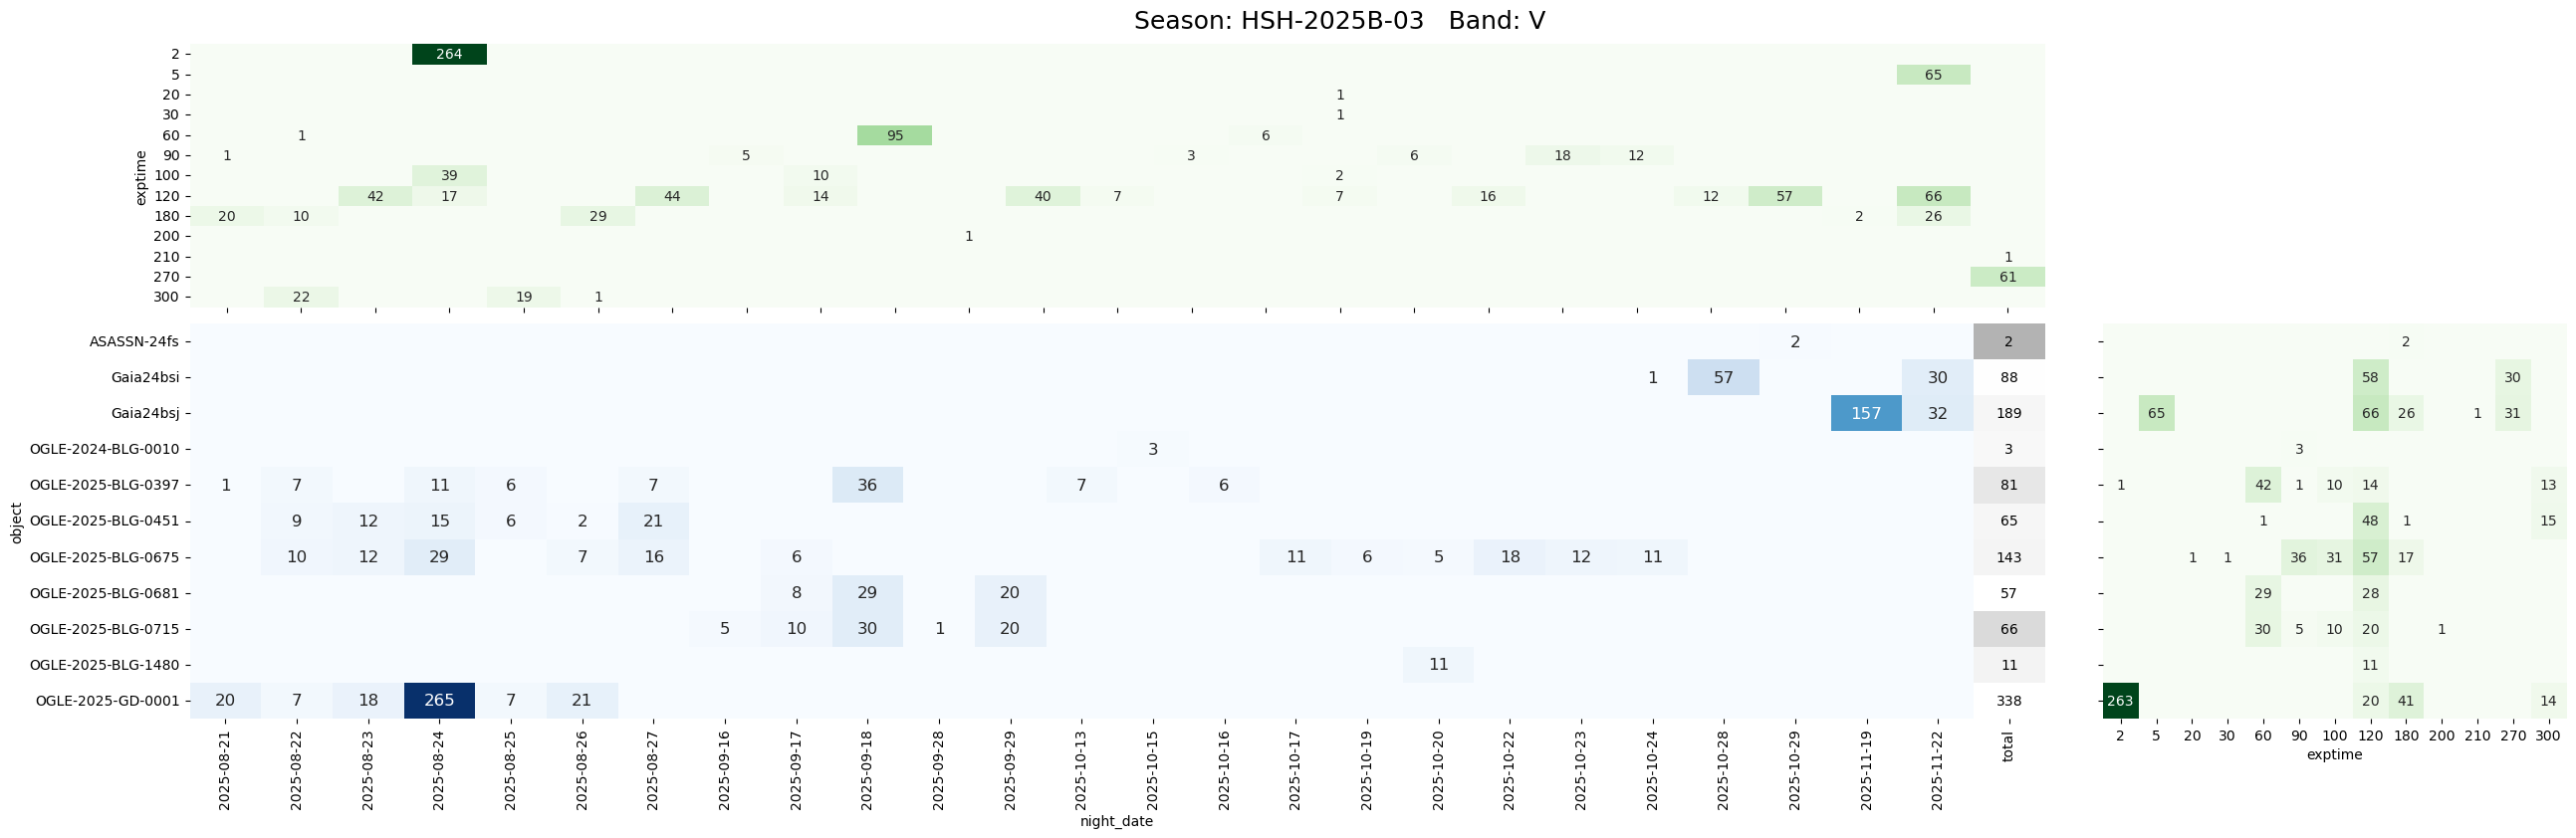

/tmp/ipykernel_59583/4290792887.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
/tmp/ipykernel_59583/4290792887.py:64: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:65: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")
/tmp/ipykernel_59583/4290792887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Ajusta márgenes


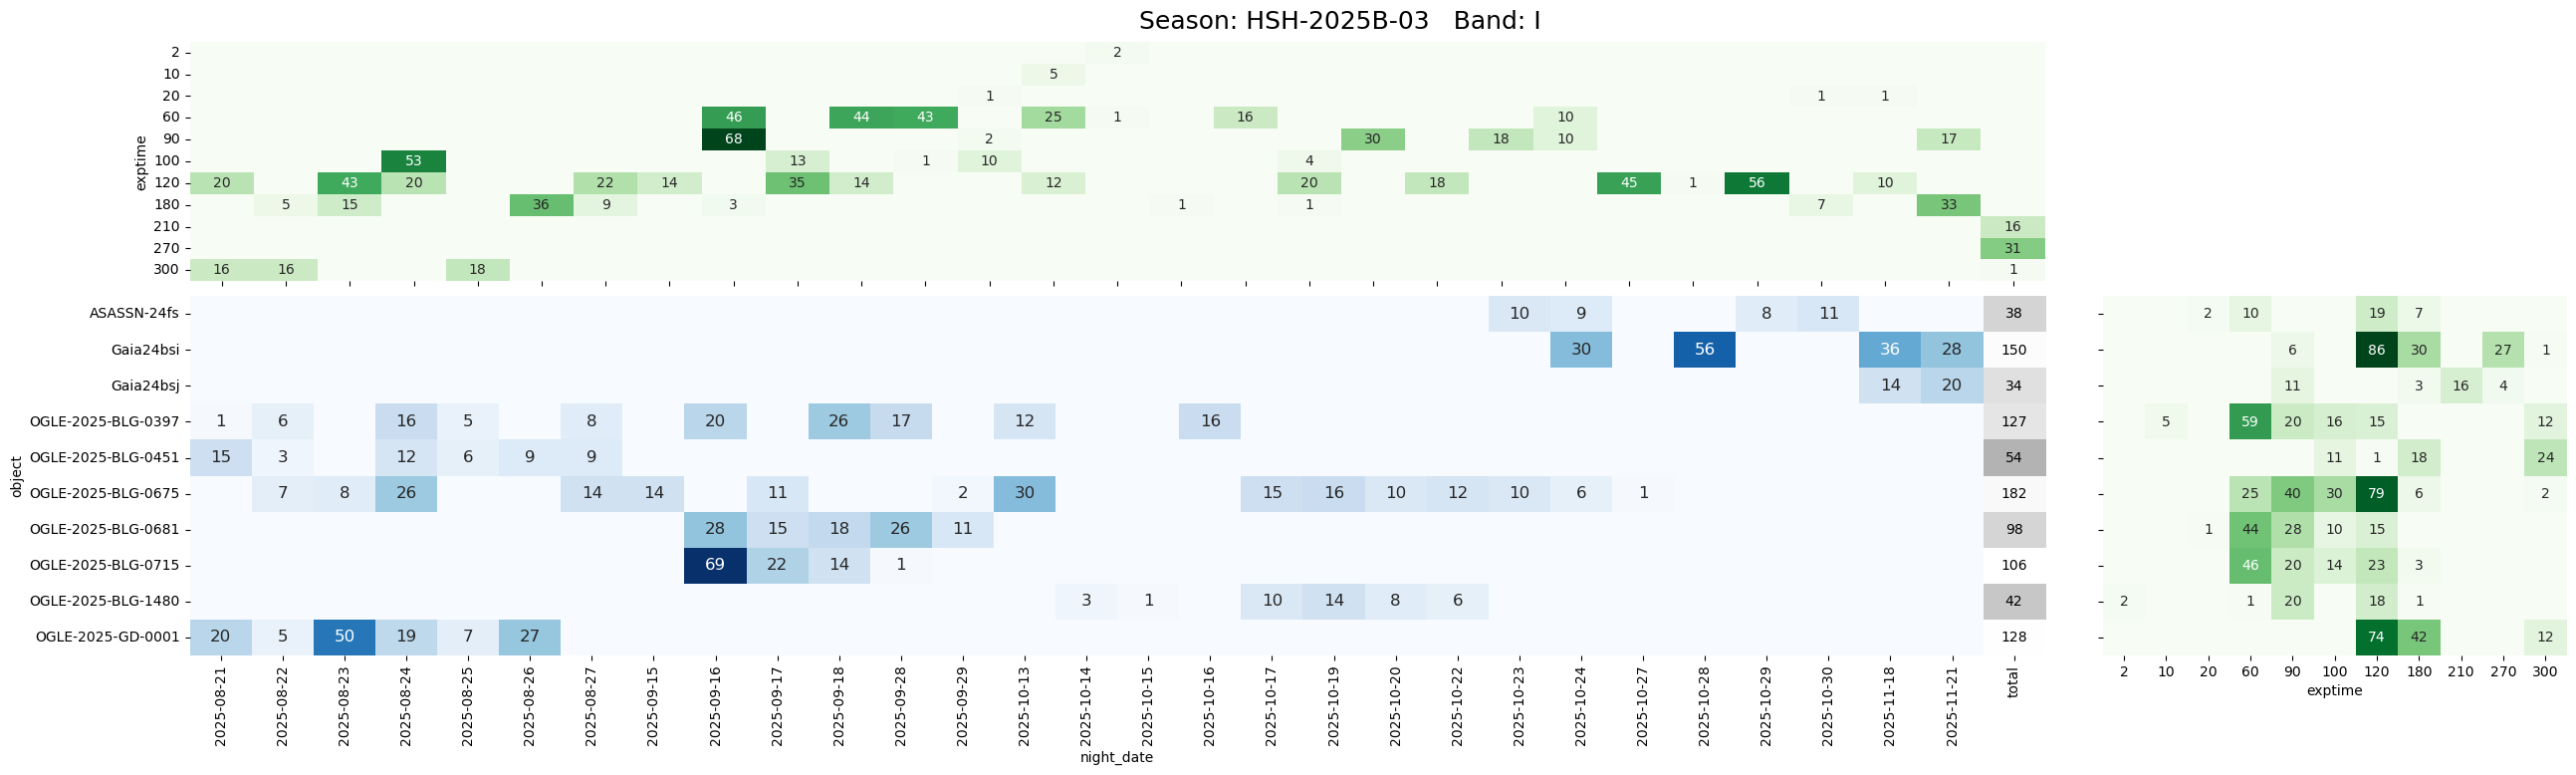

In [167]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar calendario de seasons
seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons = seasons_df["season"].unique()

# Aseguramos tipos correctos
df["night"] = pd.to_datetime(df["night"])


df["exptime"] = pd.to_numeric(df["exptime"], errors='coerce').astype(int)

# Filtrar solo objetos válidos
df_objects = df[(df["imagetyp"]=="object") & (df["object"]!="NO_OBJECT")].copy()
# Convertir night a solo fecha
df_objects["night_date"] = df_objects["night"].dt.date

# Iterar por cada season
for season in seasons:
    print(f"Plotting season: {season}")
    
    # Fechas de la season
    season_dates = seasons_df.loc[seasons_df["season"]==season, "date"]
    n_nights = len(season_dates)
    
    for band in ["(3) V","(5) I"]:
    
        # Filtrar df_objects para esa season
        df_season = df_objects[(df_objects["night"].isin(season_dates))&(df["wheel"] == band)]
        n_obj = len(df_season["object"].value_counts())
        
        
        if df_season.empty:
            print(f"No hay datos para la season {season}")
            continue
        
        # Matriz objeto × noche
        blue_matrix = (
            df_season.groupby(["object", "night_date"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index(axis=1)
        )
        blue_matrix["total"] = blue_matrix.sum(axis=1)
        
        top_green = (
            df_season.groupby(["exptime", "night_date"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index()
        )
        
        right_green = (
            df_season.groupby(["object", "exptime"])
                    .size()
                    .unstack(fill_value=0)
                    .sort_index(axis=1)
        )
        # Máscara para que "total" no reciba color de Blues
        mask_total = blue_matrix.columns.to_series().eq("total").to_numpy()  # 1D
        mask_total = np.tile(mask_total, (blue_matrix.shape[0], 1))           # 2D: filas x columnas
        annot_blue = blue_matrix.applymap(lambda x: str(x) if x != 0 else "")
        annot_top = top_green.applymap(lambda x: str(x) if x != 0 else "")
        annot_right = right_green.applymap(lambda x: str(x) if x != 0 else "")


        
        # Plot
        fig = plt.figure(figsize=(n_nights*0.55, n_obj*0.8))
        gs = fig.add_gridspec(
            2, 2,
            width_ratios=[4, 1],
            height_ratios=[2, 3],
            wspace=0.05,
            hspace=0.05
        )
        ax_top = fig.add_subplot(gs[0, 0])
        ax_main = fig.add_subplot(gs[1, 0])
        ax_right = fig.add_subplot(gs[1, 1])

        # Heatmap azul con columna "total" excluida de la escala
        sns.heatmap(
            blue_matrix,
            ax=ax_main,
            cmap="Blues",
            annot=annot_blue,
            fmt="",
            annot_kws={"size":12},
            cbar=False,
            mask=mask_total,   # Esta máscara deja "total" sin color
        )
        ax_main.imshow(
            blue_matrix[["total"]],
            cmap="Greys",
            alpha=0.3,
            aspect='auto',
            extent=[blue_matrix.shape[1]-1, blue_matrix.shape[1], 0, blue_matrix.shape[0]]
        )

        # Añadir los números manualmente
        for i, val in enumerate(blue_matrix["total"]):
            ax_main.text(
                blue_matrix.shape[1]-0.5,  # centro de la última columna
                i + 0.5,                    # centro de la fila
                int(val),
                ha='center',
                va='center'
            )


        # Heatmaps verdes
        sns.heatmap(top_green, ax=ax_top, cmap="Greens", annot=annot_top, fmt="", annot_kws={"size":10}, cbar=False)
        sns.heatmap(right_green, ax=ax_right, cmap="Greens", annot=annot_right, fmt="", annot_kws={"size":10}, cbar=False)

        band_str = band[-1]
        ax_top.set_xticklabels([])
        ax_top.set_xlabel("")
        ax_right.set_yticklabels([])
        ax_right.set_ylabel("")
        plt.suptitle(f"Season: {season}   Band: {band_str}", fontsize=18, y=0.92)
        plt.tight_layout()  # Ajusta márgenes
        plt.savefig(f"season_{season}_band_{band_str}.png", dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()  # cerrar la figura para liberar memoria



In [168]:
import matplotlib.pyplot as plt

df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")

df_obj = df[df["imagetyp"]=="object"]

plt.figure(figsize=(10,4))

for col in filter_cols:
    mask = df_obj[col].notna()
    plt.plot(df_obj.loc[mask, "night"], df_obj.loc[mask, col], "s", alpha=0.5, label=col)

plt.title("Filter keywords used per date (only imgtyp=objects)")
plt.legend()
plt.grid()


NameError: name 'filter_cols' is not defined

<Figure size 1000x400 with 0 Axes>

In [192]:
df_obj[df_obj["filter01"] == "(4) R"]

,file,simple,bitpix,naxis,naxis1,naxis2,bscale,bzero,ccdsize,ccdsum,...,dome-az,adcrate,instrmod,optele,detector,pixscale,filter01,filter02,im_filt,im_filt1
26401,track-testr0002.fit,True,16,2,1024,1024,1.0,32768.0,"[1:1024,1:1024]",1 1,...,77.4,NaN,NaN,NaN,STL-1001E,0.53,(4) R,(6) Free,(4) R,(6) Free


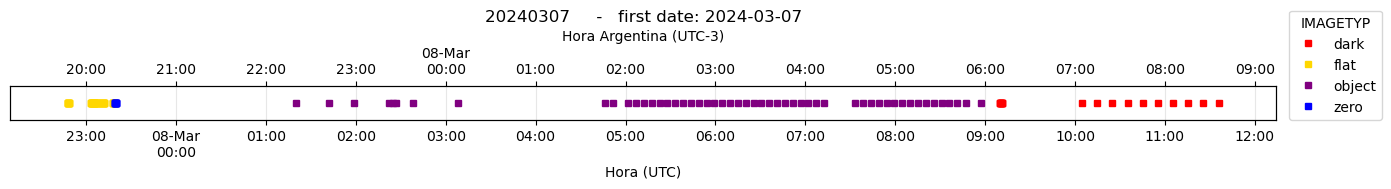

object
skyflat              60
OGLE-2023-GD-0011    44
NGC2442               4
Set Point             3
SetPoint2             1
Name: count, dtype: int64


In [ ]:
gg = check_night(df, "20240307")

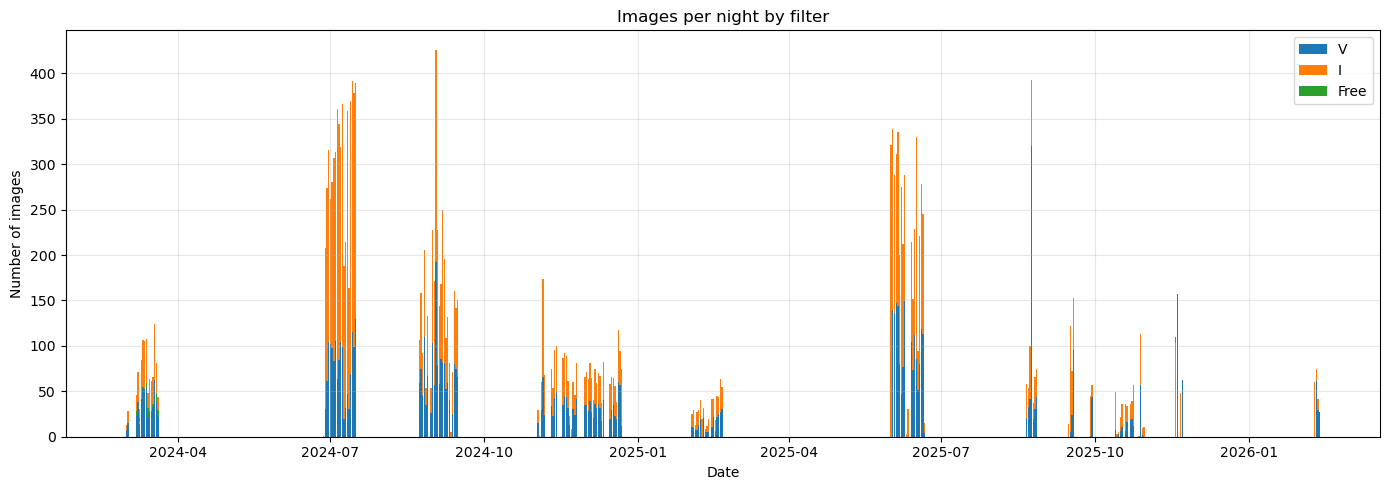

In [148]:

df_obj = df[df["imagetyp"]=="object"]
daily_counts = (
    df_obj.groupby(["night", "wheel"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
daily_counts1 = (
    df_obj.groupby(["night", "wheel_aux"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

plt.figure(figsize=(14,5))

x = daily_counts.index
v = daily_counts["(3) V"]
i = daily_counts["(5) I"]
f = daily_counts["(1) Free"]
#b = daily_counts["(2) B"]
#r = daily_counts["(4) R"]


plt.bar(x, v, label="V")
plt.bar(x, i, bottom=v, label="I") 
plt.bar(x, f, bottom=i, label="Free") 
#plt.bar(x, b, bottom=f, label="B") 
#plt.bar(x, r, bottom=b, label="R") 


plt.xlabel("Date")
plt.ylabel("Number of images")
plt.title("Images per night by filter")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [194]:
daily_counts.sum(), daily_counts1.sum()

(im_filt
 (1) Free       49
 (3) V        6659
 (4) R           2
 (5) I       11180
 dtype: int64,
 im_filt1
 (6) Free    17890
 dtype: int64)

In [149]:
count = (
    df.groupby(["imagetyp", "wheel"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
count

wheel,(1) Free,(2) B,(3) V,(4) R,(5) I
imagetyp,,,,,
dark,60,19,1364,0,1313
flat,99,112,3204,155,3269
object,57,0,7829,2,12279
zero,80,59,1386,20,1896


In [155]:
df[ "object"].value_counts()


object
OGLE-2025-BLG-0675    3208
OGLE-2024-BLG-0592    2561
OGLE-2024-BLG-0674    2411
Gaia24bsi             1645
Gaia24bsj             1420
OGLE-2024-DG-0016     1099
OGLE-2024-BLG-0669    1036
OGLE-2024-GD-0006     1018
OGLE-2024-BLG-0605     982
OGLE-2025-GD-0001      748
OGLE-2024-BLG-0034     593
ASASSN-24fs            547
NO_OBJECT              435
OGLE-2023-GD-0011      389
OGLE-2025-BLG-0397     306
Gaia24ddl              256
OGLE-2025-BLG-0451     203
OGLE-2025-BLG-0245     179
OGLE-2025-BLG-0715     172
OGLE-2024-GD-0014      172
Gaia23cnu              168
OGLE-2024-BLG-0010     162
OGLE-2025-BLG-0681     155
OGLE-2024-BLG-0002      89
OGLE-2025-BLG-1480      77
OGLE-2024-BLG-0009      59
OGLE-2024-GD-0001       42
Gaia23dpn               28
OGLE-2025-GD-0006        6
OGLE-2023-BLG-0723       1
Name: count, dtype: int64

## Analisis: sky map

-72.81730555555555 21.513833333333334
0.02333333333333333 359.64833333333326


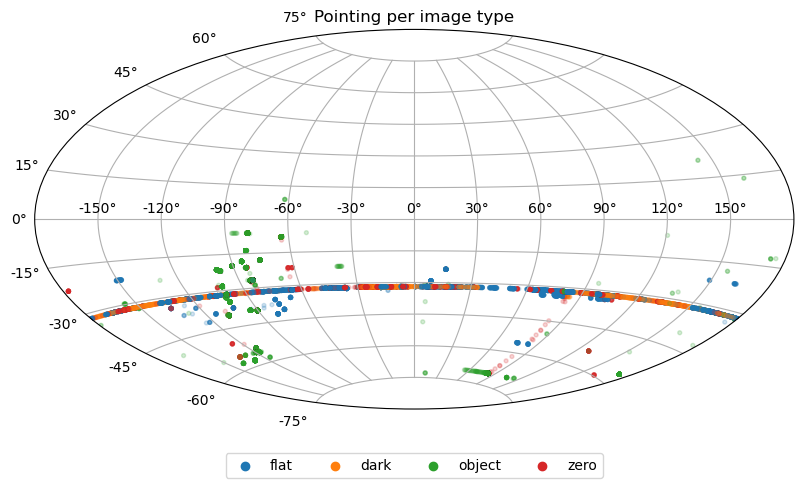

In [150]:
from astropy.coordinates import SkyCoord
import astropy.units as u


coords = SkyCoord(df['ra2000'], df['dec2000'], unit=(u.hourangle, u.deg))
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

print(coords.dec.deg.min(), coords.dec.deg.max())  # debería estar entre ~-90 y +60
print(coords.ra.deg.min(), coords.ra.deg.max())    # RA entre 0 y 360°

import matplotlib.pyplot as plt
import numpy as np

# Obtener categorías únicas
types = df['imagetyp'].unique()

# Definir un colormap discreto
cmap = plt.get_cmap('tab10')  # bueno para <=10 categorías
colors = {t: cmap(i) for i, t in enumerate(types)}

# Crear array de colores alineado con los puntos
point_colors = df['imagetyp'].map(colors)

# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')

sc = ax.scatter(ra_rad, dec_rad, 
                c=point_colors,
                alpha=0.2, 
                s=8)

ax.grid(True)
ax.set_title("Pointing per image type")
ax.invert_xaxis()

# Crear leyenda manual
for t in types:
    ax.scatter([], [], c=[colors[t]], label=t)

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
          ncol=min(len(types), 4))

plt.tight_layout()
plt.show()

-70.14630555555556 -6.077166666666667
78.22208333333332 297.01041666666663


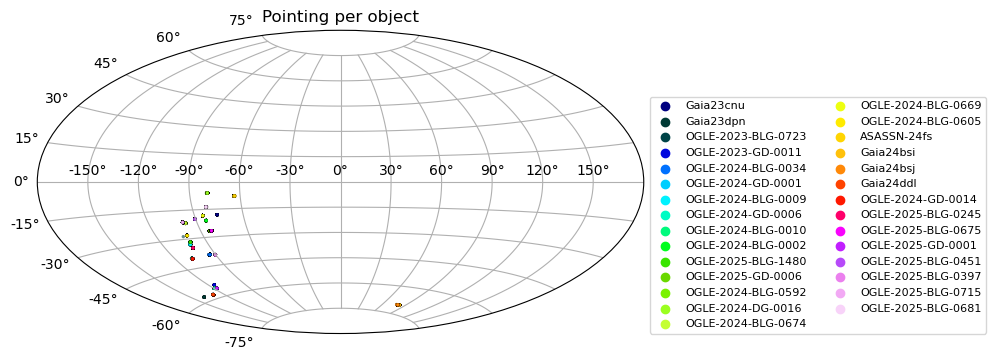

In [153]:
from astropy.coordinates import SkyCoord
import astropy.units as u


df_object = df[df["imagetyp"] == "object"]
df_object = df_object[df_object['object'] != "NO_OBJECT"].copy()
coords = SkyCoord(df_object['ra2000'], df_object['dec2000'], unit=(u.hourangle, u.deg))
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

print(coords.dec.deg.min(), coords.dec.deg.max())  # debería estar entre ~-90 y +60
print(coords.ra.deg.min(), coords.ra.deg.max())    # RA entre 0 y 360°

import matplotlib.pyplot as plt
import numpy as np

# Obtener categorías únicas
types = df_object['object'].unique()


#cmap = plt.get_cmap('tab10')
#colors = {t: cmap(i) for i, t in enumerate(types)}
#point_colors = df_object['object'].map(colors)

N = len(types)
cmap = plt.get_cmap('gist_ncar')
colors_list = [cmap(i / N) for i in range(N)]
colors = dict(zip(types, colors_list))
point_colors = df_object['object'].map(colors)


# Plot
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')

sc = ax.scatter(ra_rad, dec_rad, 
                marker=".",
                c=point_colors,
                alpha=0.6, 
                edgecolor="black",
                linewidths=0.1,
                s=20)

ax.grid(True)
ax.set_title("Pointing per object")
ax.invert_xaxis()

# Crear leyenda manual
for t in types:
    ax.scatter([], [], c=[colors[t]], label=t)

ax.legend(loc=(1.01,0), ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

Dec min/max hemisferio sur: -70.14630555555556 -6.077166666666667
RA min/max hemisferio sur: 78.22208333333332 297.01041666666663


/tmp/ipykernel_59583/1395061380.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


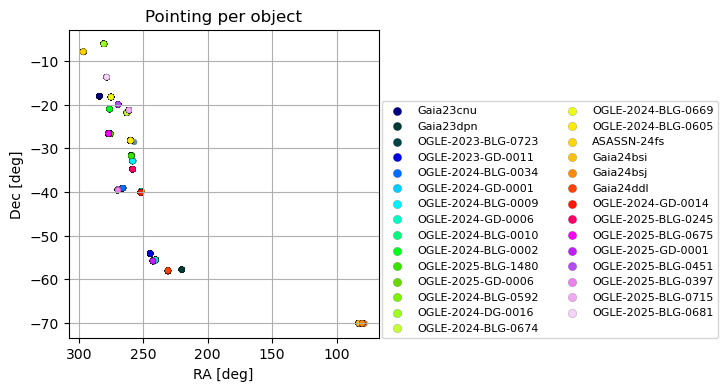

In [156]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

# Filtrar objetos válidos
df_object = df[df["imagetyp"] == "object"].copy()
df_object = df_object[df_object['object'] != "NO_OBJECT"]

# Coordenadas
coords = SkyCoord(df_object['ra2000'], df_object['dec2000'], unit=(u.hourangle, u.deg))

# Solo hemisferio sur
mask_south = coords.dec.deg <= 0
ra_south = coords.ra.deg[mask_south]
dec_south = coords.dec.deg[mask_south]
objects_south = df_object['object'][mask_south]

print("Dec min/max hemisferio sur:", dec_south.min(), dec_south.max())
print("RA min/max hemisferio sur:", ra_south.min(), ra_south.max())

# Colores
types = objects_south.unique()
N = len(types)
cmap = plt.get_cmap('gist_ncar')
colors_list = [cmap(i / N) for i in range(N)]
colors = dict(zip(types, colors_list))
point_colors = objects_south.map(colors)

# Plot cartesiano
fig, ax = plt.subplots(figsize=(4,4))
sc = ax.scatter(
    ra_south, dec_south,
    c=point_colors,
    edgecolor="black",
    linewidths=0.1,
    alpha=0.6,
    s=18,
    #marker="."
)

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Pointing per object")
ax.invert_xaxis()  # opcional: RA decreciente
ax.grid(True)

# Leyenda
for t in types:
    ax.scatter([], [], c=[colors[t]], edgecolor="black", linewidths=0.1, label=t)
ax.legend(loc=(1.01,0), fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ==============================
# RUTA AL CATÁLOGO DE OBJETOS
# ==============================
CATALOG_PATH = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/objetos.csv"

# ==============================
# CARGAR CATÁLOGO
# ==============================
cat = pd.read_csv(CATALOG_PATH)

cat_coords = SkyCoord(
    ra=cat["ra_deg"].values * u.deg,
    dec=cat["dec_deg"].values * u.deg
)

# ==============================
# COPIA DEL DATAFRAME DE IMÁGENES
# (debe tener: ra2000, dec2000, object)
# ==============================


img_coords = SkyCoord(
    df["ra2000"].astype(str).values,
    df["dec2000"].astype(str).values,
    unit=(u.hourangle, u.deg)
)


# ==============================
# CROSS-MATCH CON CATÁLOGO
# ==============================
idx, sep2d, _ = img_coords.match_to_catalog_sky(cat_coords)

df["orig_obj"] = df["object"]
df["nearest_obj"] = cat.loc[idx, "objeto"].values
df["sep_arcsec"] = sep2d.arcsec

# ==============================
# COMPARACIÓN DE NOMBRES
# ==============================
df["name_match"] = df["object"] == df["nearest_obj"]

# ==============================
# UMBRAL DE DISTANCIA ANGULAR
# ==============================
MAX_SEP = 250  # arcsec
df["close_match"] = df["sep_arcsec"] < MAX_SEP

# ==============================
# CASOS CON NOMBRE INCORRECTO
# ==============================
wrong_name = df[(df["close_match"]) & (~df["name_match"]) & (df["imagetyp"] == "object")]

print("\nImágenes con nombre incorrecto pero posición correcta:")
print(wrong_name[["object", "nearest_obj", "sep_arcsec"]].head())
print(f"Total: {len(wrong_name)}")

# ==============================
# CASOS SIN OBJETO CERCANO
# ==============================
no_object = df[~df["close_match"] & (df["imagetyp"] == "object")]

print("\nImágenes sin objeto cercano en catálogo:")
print(no_object[["object", "ra2000", "dec2000", "sep_arcsec"]].head())
print(f"Total: {len(no_object)}")

# ==============================
# CORRECCIÓN AUTOMÁTICA (OPCIONAL)
# ==============================
AUTO_FIX = False  # Cambiar a True para corregir nombres

if AUTO_FIX:
    mask_fix = (df["close_match"]) & (~df["name_match"])
    df.loc[mask_fix, "object"] = df.loc[mask_fix, "nearest_obj"]
    print(f"\n✔️ Corregidos {mask_fix.sum()} nombres automáticamente")

# ==============================
# GUARDAR RESULTADOS
# ==============================
#df.to_csv("image_object_crossmatch_results.csv", index=False)

#print("\nArchivo guardado: image_object_crossmatch_results.csv")
#print("Proceso terminado correctamente.")



Imágenes con nombre incorrecto pero posición correcta:
          object         nearest_obj  sep_arcsec
0  OGLE-BLG-0592  OGLE-2024-BLG-0592   52.598487
1  OGLE-BLG-0592  OGLE-2024-BLG-0592   52.598487
2  OGLE-BLG-0592  OGLE-2024-BLG-0592   52.830296
3  OGLE-BLG-0592  OGLE-2024-BLG-0592   52.533534
4  OGLE-BLG-0592  OGLE-2024-BLG-0592   52.897646
Total: 4492

Imágenes sin objeto cercano en catálogo:
        object      ra2000      dec2000     sep_arcsec
707    NGC2442  07:36:46.7  -69:33:23.1   38879.521773
708    NGC2442  07:36:55.9  -69:29:57.5   38987.353990
709    NGC2442  07:36:55.8  -69:29:57.5   38986.853369
710    NGC2442  07:36:55.9  -69:29:57.5   38987.353990
755  SetPoint2  09:12:11.9  -27:14:51.3  190638.495691
Total: 942


In [11]:
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# ==============================
# RUTA AL CATÁLOGO DE OBJETOS
# ==============================
CATALOG_PATH = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/objetos.csv"

# ==============================
# CARGAR CATÁLOGO
# ==============================
cat = pd.read_csv(CATALOG_PATH)

cat_coords = SkyCoord(
    ra=cat["ra_deg"].values * u.deg,
    dec=cat["dec_deg"].values * u.deg
)

# ==============================
# DATAFRAME DE IMÁGENES
# ==============================
# df debe existir con columnas: ra2000, dec2000, object
img_coords = SkyCoord(
    df["ra2000"].astype(str).values,
    df["dec2000"].astype(str).values,
    unit=(u.hourangle, u.deg)
)

# ==============================
# CROSS-MATCH
# ==============================
idx, sep2d, _ = img_coords.match_to_catalog_sky(cat_coords)

df["orig_obj"] = df["object"]  # Guardar nombre original siempre
df["nearest_obj"] = cat.loc[idx, "objeto"].values
df["sep_arcsec"] = sep2d.arcsec

# ==============================
# COMPARACIÓN DE NOMBRES
# ==============================
df["name_match"] = df["object"] == df["nearest_obj"]

# ==============================
# UMBRAL DE DISTANCIA ANGULAR
# ==============================
MAX_SEP = 250  # arcsec
df["close_match"] = df["sep_arcsec"] < MAX_SEP

# ==============================
# CASOS CON NOMBRE INCORRECTO
# ==============================
wrong_name = df[(df["close_match"]) & (~df["name_match"]) & (df["imagetyp"] == "object")]
print("\nWRONG NAME + MATCH OBJECT:")
print(f"Total: {len(wrong_name)}")

# ==============================
# CASOS SIN OBJETO CERCANO
# ==============================
no_object = df[~df["close_match"] & (df["imagetyp"] == "object")]
print("\nNO MATCH OBJECT")
print(f"Total: {len(no_object)}")

# ==============================
# DOBLE CHECK ANTES DE CORREGIR
# ==============================

approve_changes = True
if len(wrong_name) > 0:
    # Agrupar por nombre original y nearest_obj
    summary = (wrong_name
               .groupby(["object", "nearest_obj"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))

    print("\nResumen de cambios propuestos (agrupado por object -> nearest_obj):")
    print(summary)  # mostrar solo los 20 más frecuentes

    #approve_changes = input("\n¿Desea reemplazar los nombres incorrectos por 'nearest_obj'? (s/n): ").lower()
    if approve_changes == True:
        mask_fix = (df["close_match"]) & (~df["name_match"])
        df.loc[mask_fix, "object"] = df.loc[mask_fix, "nearest_obj"]
        print(f"\n✔️ Se corrigieron {mask_fix.sum()} nombres automáticamente")
    else: #if isinstance(approve, int):
        #print(summary.loc[approve])
        #correct = input("Input correct object name: ")
        print("\n❌ No se hicieron cambios. Revise los nombres manualmente.")



mark_wrong = True
if len(no_object) > 0:
    print("\n❗ Atención: hay imágenes sin un objeto cercano en el catálogo.")
    summary_noobj = (no_object
               .groupby(["object", "nearest_obj"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))
    print(no_object[["object", "ra2000", "dec2000", "sep_arcsec"]].head())
    if mark_wrong:
        df.loc[no_object.index, "object"] = "NO_OBJECT"



WRONG NAME + MATCH OBJECT:
Total: 0

NO MATCH OBJECT
Total: 942

❗ Atención: hay imágenes sin un objeto cercano en el catálogo.
        object      ra2000      dec2000     sep_arcsec
707    NGC2442  07:36:46.7  -69:33:23.1   38879.521773
708    NGC2442  07:36:55.9  -69:29:57.5   38987.353990
709    NGC2442  07:36:55.8  -69:29:57.5   38986.853369
710    NGC2442  07:36:55.9  -69:29:57.5   38987.353990
755  SetPoint2  09:12:11.9  -27:14:51.3  190638.495691


In [15]:
df[(df["object"]=="OGLE-2024-GD-0014")&(df["nearest_obj"]=="Gaia24ddl")][["file", "object", "nearest_obj", "close_match", "name_match", "sep_arcsec", "ra2000", "dec2000", "exptime", "date-obs", "time-obs", "night"]]

,file,object,nearest_obj,close_match,name_match,sep_arcsec,ra2000,dec2000,exptime,date-obs,time-obs,night
21666,Gaia24ddli0001.fit,OGLE-2024-GD-0014,Gaia24ddl,True,False,201.370441,15:23:12.7,-58:01:53.4,180.0,2025-02-12,07:10:06.092,20250211
21667,Gaia24ddli0002.fit,OGLE-2024-GD-0014,Gaia24ddl,True,False,201.679778,15:23:12.6,-58:01:53.3,300.0,2025-02-12,07:13:42.713,20250211
21668,Gaia24ddlv0001.fit,OGLE-2024-GD-0014,Gaia24ddl,True,False,201.895624,15:23:12.5,-58:01:53.3,180.0,2025-02-12,07:27:05.372,20250211
21669,Gaia24ddlv0002.fit,OGLE-2024-GD-0014,Gaia24ddl,True,False,202.560434,15:23:12.2,-58:01:53.3,180.0,2025-02-12,07:30:13.809,20250211


In [16]:
df["object"].value_counts()

object
OGLE-2025-BLG-0675    2954
OGLE-2024-BLG-0592    2598
OGLE-2024-BLG-0674    2316
Gaia24bsi             1355
Gaia24bsj             1155
OGLE-2024-DG-0016     1044
OGLE-2024-BLG-0669    1036
OGLE-2024-GD-0006      981
OGLE-2024-BLG-0605     957
NO_OBJECT              942
OGLE-2024-BLG-0034     579
ASASSN-24fs            507
OGLE-2023-GD-0011      409
OGLE-2025-GD-0001      272
skyflat                263
OGLE-2024-GD-0014      199
Gaia24ddl              194
Gaia23cnu              188
OGLE-2025-BLG-0245     179
OGLE-2024-BLG-0010     159
flat                   125
OGLE-2024-BLG-0002     117
OGLE-2025-BLG-0397      98
OGLE-2025-BLG-0451      96
OGLE-2024-BLG-0009      51
OGLE-2024-GD-0001       43
Gaia23dpn               28
OGLE-2023-BLG-0723       8
Name: count, dtype: int64

In [13]:
no_object[no_object["imagetyp"]=="object"][["file", "object", "nearest_obj", "close_match", "name_match", "sep_arcsec", "ra2000", "dec2000", "exptime", "date-obs", "time-obs", "night"]].head(30)

,file,object,nearest_obj,close_match,name_match,sep_arcsec,ra2000,dec2000,exptime,date-obs,time-obs,night
707,NGC2442_f0005.fit,NGC2442,Gaia24bsi,False,False,38879.521773,07:36:46.7,-69:33:23.1,160.0,2024-03-08,03:07:51.921,20240307
708,NGC2442_i0003.fit,NGC2442,Gaia24bsi,False,False,38987.353990,07:36:55.9,-69:29:57.5,120.0,2024-03-08,02:26:44.560,20240307
709,NGC2442_r0002.fit,NGC2442,Gaia24bsi,False,False,38986.853369,07:36:55.8,-69:29:57.5,120.0,2024-03-08,02:24:33.657,20240307
710,NGC2442_v0001.fit,NGC2442,Gaia24bsi,False,False,38987.353990,07:36:55.9,-69:29:57.5,120.0,2024-03-08,02:22:22.688,20240307
755,SetPoint2_f0001.fit,SetPoint2,Gaia24bsi,False,False,190638.495691,09:12:11.9,-27:14:51.3,20.0,2024-03-08,02:38:08.709,20240307
756,SetPoint_f0001.fit,Set Point,Gaia24bsi,False,False,153083.362503,07:43:34.4,-31:43:46.1,5.0,2024-03-08,01:20:21.156,20240307
757,SetPoint_f0002.fit,Set Point,Gaia24bsi,False,False,159454.011685,08:11:21.6,-31:42:55.0,5.0,2024-03-08,01:42:03.960,20240307
758,_f0001.fit,Set Point,Gaia24bsi,False,False,38535.358192,07:36:24.0,-69:46:43.6,60.0,2024-03-08,01:58:31.487,20240307
1042,focusv0001.fit,focus,Gaia23dpn,False,False,175624.627137,10:33:36.3,-31:39:51.1,10.0,2024-03-09,04:36:39.720,20240308
1043,focusv0002.fit,focus,Gaia23dpn,False,False,175623.829600,10:33:36.4,-31:39:51.1,10.0,2024-03-09,04:36:57.689,20240308


284.10600,-18.08080,18:56:25.44,-18:04:50.88

In [ ]:
wrong_name[["object", "nearest_obj", "close_match", "name_match", "ra2000", "dec2000", "exptime", "date-obs", "time-obs", "night"]]#.iloc[800:900]

,object,nearest_obj,close_match,name_match,ra2000,dec2000,exptime,date-obs,time-obs,night
11033,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.2,-26:39:35.2,60.0,2024-08-27,04:21:35.472,2024-08-26
11034,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.2,-26:39:35.2,60.0,2024-08-27,04:22:43.612,2024-08-26
11035,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.2,-26:39:35.2,60.0,2024-08-27,04:23:51.750,2024-08-26
11036,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.0,-26:39:35.2,60.0,2024-08-27,04:24:59.892,2024-08-26
11037,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.1,-26:39:35.2,60.0,2024-08-27,04:26:08.089,2024-08-26
11038,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.1,-26:39:35.2,60.0,2024-08-27,04:27:16.231,2024-08-26
11039,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.0,-26:39:35.2,60.0,2024-08-27,04:28:24.309,2024-08-26
11040,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:53.9,-26:39:35.2,60.0,2024-08-27,04:29:32.453,2024-08-26
11041,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.4,-26:39:35.2,60.0,2024-08-27,04:04:29.433,2024-08-26
11042,OGLE-BLG-0592,OGLE-2024-BLG-0592,True,False,18:23:54.7,-26:39:35.2,60.0,2024-08-27,04:05:37.568,2024-08-26


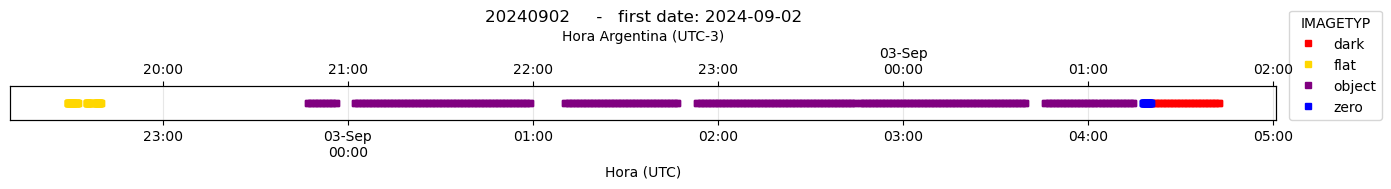

object
OGLE-BLG-0669         188
OGLE-2024-BLG-0592    186
OGLE-BLG-0592          52
Name: count, dtype: int64


In [ ]:
df_obj = check_night(df, "20240902")

In [237]:
df_obj.columns

Index(['file', 'simple', 'bitpix', 'naxis', 'naxis1', 'naxis2', 'bscale',
       'bzero', 'ccdsize', 'ccdsum',
       ...
       'instrmod', 'optele', 'detector', 'pixscale', 'filter01', 'filter02',
       'im_filt', 'im_filt1', 'datetime', 'datetime_ar'],
      dtype='object', length=103)

In [238]:
df_obj[["object", "ra2000", "dec2000", "exptime", "date-obs", 'datetime_ar', "night"]].sort_values('datetime_ar')

,object,ra2000,dec2000,exptime,date-obs,datetime_ar,night
276,NaN,15:38:07.3,-31:42:24.1,0.5,2024-09-02,2024-09-02 19:29:08.119,2024-09-02
12624,NaN,15:38:07.3,-31:42:24.1,0.5,2024-09-02,2024-09-02 19:29:08.119,2024-09-02
277,NaN,15:38:15.5,-31:42:24.4,0.5,2024-09-02,2024-09-02 19:29:16.167,2024-09-02
12625,NaN,15:38:15.5,-31:42:24.4,0.5,2024-09-02,2024-09-02 19:29:16.167,2024-09-02
278,NaN,15:38:23.6,-31:42:24.6,0.5,2024-09-02,2024-09-02 19:29:24.401,2024-09-02
12626,NaN,15:38:23.6,-31:42:24.6,0.5,2024-09-02,2024-09-02 19:29:24.401,2024-09-02
279,NaN,15:38:31.8,-31:42:24.9,0.5,2024-09-02,2024-09-02 19:29:32.639,2024-09-02
12627,NaN,15:38:31.8,-31:42:24.9,0.5,2024-09-02,2024-09-02 19:29:32.639,2024-09-02
280,NaN,15:38:40.1,-31:42:25.1,0.5,2024-09-02,2024-09-02 19:29:40.941,2024-09-02
12628,NaN,15:38:40.1,-31:42:25.1,0.5,2024-09-02,2024-09-02 19:29:40.941,2024-09-02


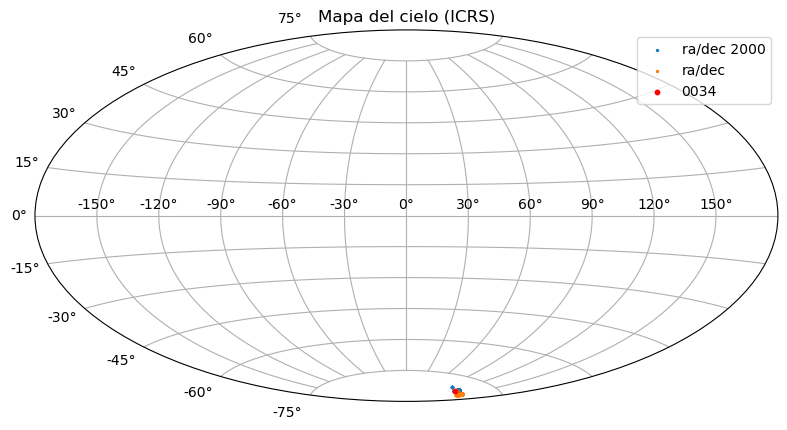

In [115]:
import matplotlib.pyplot as plt
from utils import load_config, Tee, load_target_coordinates
ra_obj, dec_obj = load_target_coordinates("OGLE-2024-BLG-0034", "data/objetos/objetos.csv")
from astropy.coordinates import SkyCoord
import astropy.units as u

df_filt = df[df["object"].str.contains("0034").astype(bool) & ~df["object"].isna()]
#df_filt = df[df["filter"]== "(3) V"]
# Coordenadas originales (catálogo)
c_cat = SkyCoord(df_filt['ra2000'].values,
                 df_filt['dec2000'].values,
                 unit=(u.hourangle, u.deg),
                 frame='icrs')

# Coordenadas medidas (detección)
c_det = SkyCoord(df_filt['ra'].values,
                 df_filt['dec'].values,
                 unit=(u.hourangle, u.deg),
                 frame='icrs')

sep_arcsec = c_cat.separation(c_det).arcsec
sep_arcmin = sep_arcsec / 60
c_obj = SkyCoord(ra_obj, dec_obj, unit=(u.deg, u.deg), frame='icrs')

plt.figure(figsize=(8,5))
ax = plt.subplot(111, projection="aitoff")

ax.scatter(c_cat.ra.value,c_cat.dec.value, s=2,  label="ra/dec 2000")
ax.scatter(c_det.ra.value,c_det.dec.value, s=2,  label="ra/dec")
ax.scatter(c_obj.ra.value,c_obj.dec.value, s=10, c="r", label="0034")
ax.legend()

ax.grid(True)
plt.title("Mapa del cielo (ICRS)")
plt.tight_layout()
plt.show()


## Análisis: por fecha

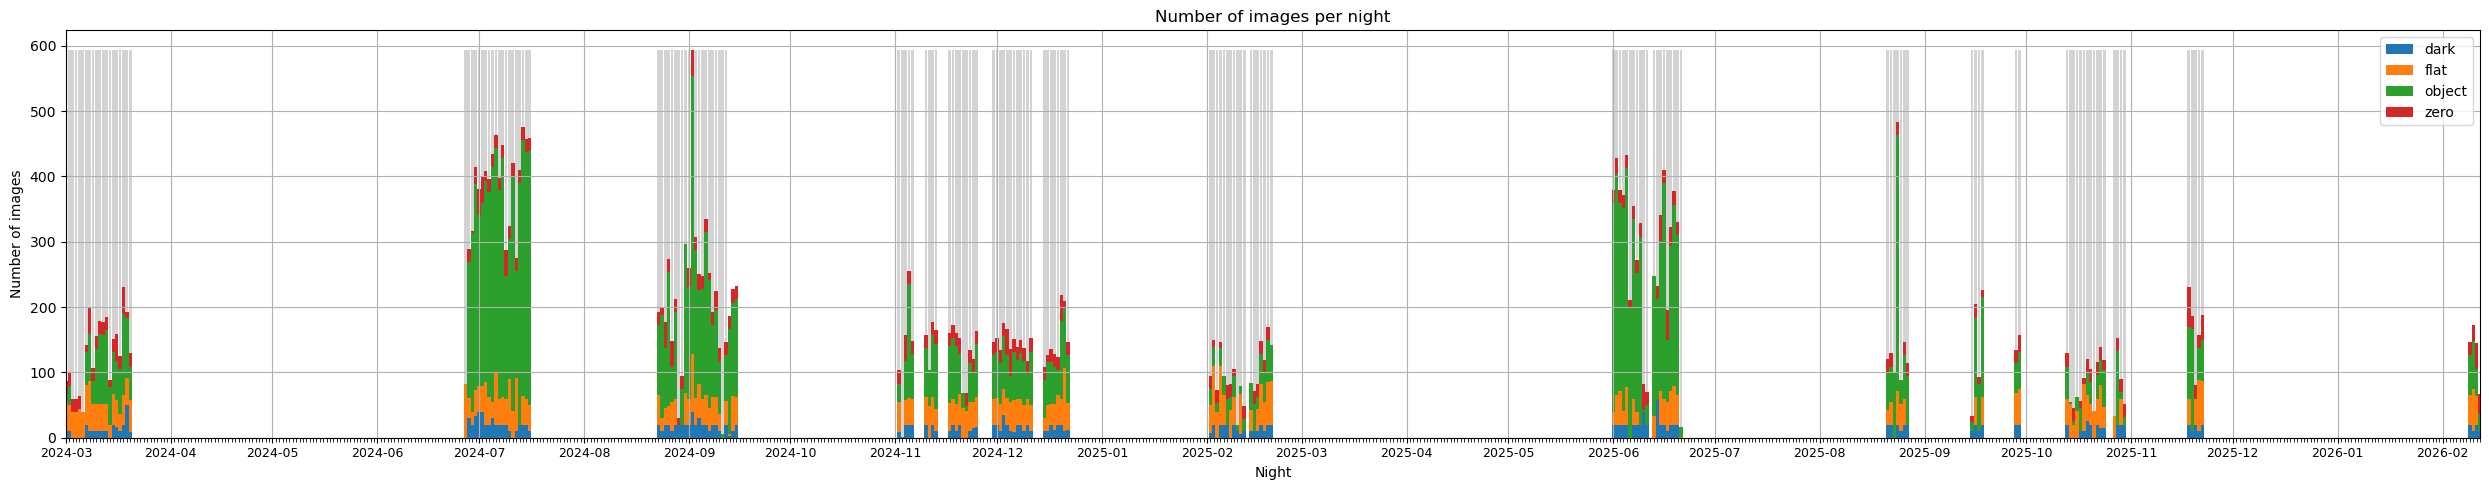

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates




# Asegúrate de que la fecha sea datetime
df['night'] = pd.to_datetime(df['night'])

# Conteo de imágenes por noche
imgs_per_night = (
    df.groupby('night')
      .size()
      .rename('n_images')
      .sort_index()
)
imgs_per_night.index = pd.to_datetime(imgs_per_night.index)

#imgs_per_night.index.to_numpy() = pd.to_datetime(imgs_per_night.index).to_numpy()
imgs_per_night = imgs_per_night.sort_index()

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')


season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:red"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)


x = merged['date'].to_numpy()
y = merged['n_images'].to_numpy()
c = colors.to_numpy()



df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")

# 2️⃣ Tabla de conteos
counts = (
    df.groupby(["night", "imagetyp"])
       .size()
       .unstack(fill_value=0)
       .sort_index()
)

fig, ax = plt.subplots(figsize=(25,5))

y_max=max(y)
for xi in x:
    if xi in seasons_df["date"].values:
        plt.bar(xi, y_max, color="lightgray")
plt.bar(x, y, width=1.0, color=c)

bottom = None
for col in counts.columns:
    ax.bar(counts.index, counts[col], bottom=bottom, width=1, label=col)
    bottom = counts[col] if bottom is None else bottom + counts[col]

# Ahora SÍ es eje datetime real
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

ax.tick_params(axis='x', which='major', rotation=0, labelsize=9)
ax.tick_params(axis='x', which='minor', length=3)

ax.set_xlabel("Night")
ax.set_ylabel("Number of images")

plt.xlim(df["night"].min(), df["night"].max())

plt.title("Number of images per night")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()



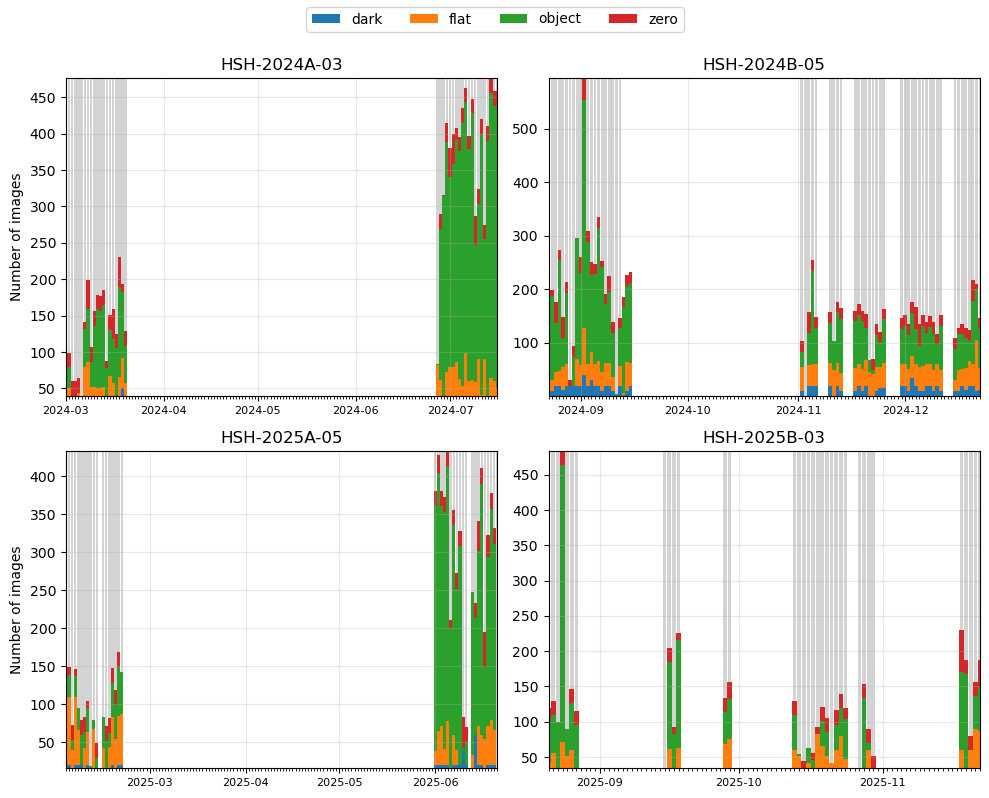

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates




# Asegúrate de que la fecha sea datetime
df['night'] = pd.to_datetime(df['night'])

# Conteo de imágenes por noche
imgs_per_night = (
    df.groupby('night')
      .size()
      .rename('n_images')
      .sort_index()
)
imgs_per_night.index = pd.to_datetime(imgs_per_night.index)

#imgs_per_night.index.to_numpy() = pd.to_datetime(imgs_per_night.index).to_numpy()
imgs_per_night = imgs_per_night.sort_index()

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')


season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:red"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)



c = colors.to_numpy()



df["night"] = pd.to_datetime(df["night"], format="%Y%m%d", errors="coerce")
df = df.sort_values("night")

# 2️⃣ Tabla de conteos
counts = (
    df.groupby(["night", "imagetyp"])
       .size()
       .unstack(fill_value=0)
       .sort_index()
)


seasons = list(season_colors.keys())
fig, axes = plt.subplots(2, 2, figsize=(10, 8))#, sharey=True)
axes = axes.flatten()

for ax, season in zip(axes, seasons):
    season_df= seasons_df[seasons_df["season"]==season]
    merged_season = merged[merged["season"]==season]
    if merged_season.empty:
        ax.set_title(f"{season} (no data)")
        continue
    x = merged_season['date'].to_numpy()
    y = merged_season['n_images'].to_numpy()
    y_max = max(y)
    for xi in x:
        if xi in season_df["date"].values:
            ax.bar(xi, y_max, color="lightgray")
    ax.bar(x, y, width=1.0, color=c)


    bottom = None
    for col in counts.columns:
        ax.bar(counts.index, counts[col], bottom=bottom, width=1, label=col)
        bottom = counts[col] if bottom is None else bottom + counts[col]
 
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.set_ylim(y.min(), y.max())
    ax.set_xlim(x.min(), x.max())

    ax.set_title(season)
    ax.grid(alpha=0.3)

# Etiquetas y leyenda
axes[0].set_ylabel("Number of images")
axes[2].set_ylabel("Number of images")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels))

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [172]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
def check_night(df, day):
    if not "-" in str(day):
        df_day = df[df["night"] == day].copy()
    else:
        df_day = df[df["date-obs"].dt.date == pd.to_datetime(day).date()].copy()
    dt_utc = pd.to_datetime(
        df_day["date-obs"].dt.strftime("%Y-%m-%d") + " " + df_day["time-obs"].astype(str),
        errors="coerce"
    )

    df_day["datetime"] = dt_utc  # 🔥 guardar para poder plotear
    df_day["datetime_ar"] = df_day["datetime"] - pd.Timedelta(hours=3)
    def ar_hour_formatter(x, pos=None):
        dt_utc = mdates.num2date(x)              # valor original en UTC
        dt_ar = dt_utc - pd.Timedelta(hours=3)  # convertir a AR manualmente
        
        if dt_ar.hour == 0 and dt_ar.minute == 0:
            return dt_ar.strftime('%d-%b\n%H:%M')
        return dt_ar.strftime('%H:%M')



    df_day["imagetyp"] = df_day["imagetyp"].str.lower().str.strip()

    color_map = {
        "flat": "gold",
        "dark": "red",
        "zero": "blue",
        "object": "purple"
    }

    plt.figure(figsize=(14, 2))

    for typ, group in df_day.groupby("imagetyp"):   #  usar df_day
        plt.plot(
            group["datetime"].to_numpy(),   #  convertir a numpy
            np.ones(len(group)),            #  también numpy
            "s",
            label=typ,
            color=color_map.get(typ, "gray"),
            markersize=5
        )


    plt.gca().yaxis.set_visible(False)
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.xlabel("Hora (UTC)")
    first_day = df_day["datetime"].min().date()
    plt.title(f"{day}     -   first date: {first_day}")
    plt.grid(True, axis='x', alpha=0.3)

    plt.legend(title="IMAGETYP", loc=(1.01,0))

    import matplotlib.ticker as mticker

    def day_hour_formatter(x, pos=None):
        dt = mdates.num2date(x)
        
        # Si es medianoche, mostramos fecha + hora
        if dt.hour == 0 and dt.minute == 0:
            return dt.strftime('%d-%b\n%H:%M')  # salto de línea
        else:
            return dt.strftime('%H:%M')

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(day_hour_formatter))
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(ar_hour_formatter))
    ax2.set_xlabel("Hora Argentina (UTC-3)")


    plt.tight_layout()
    plt.show()
    print(df_day.object.value_counts())
    return df_day

#### Seasons

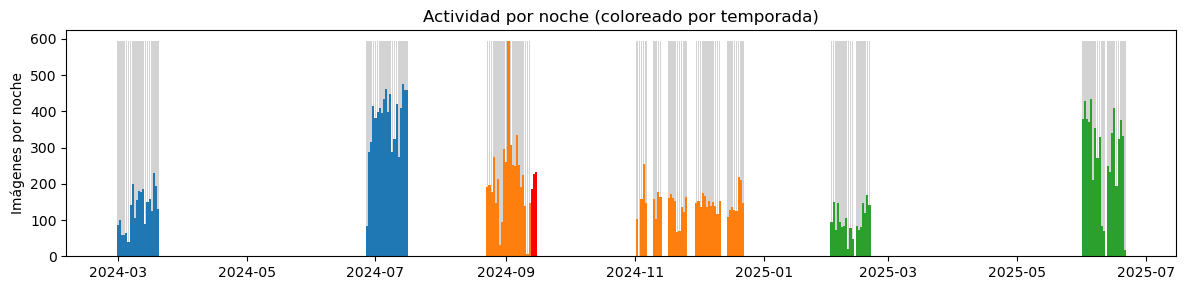

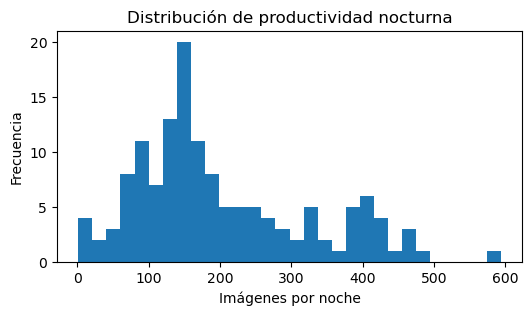

In [58]:
import matplotlib.pyplot as plt

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')

import matplotlib.pyplot as plt

season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:red"
}

# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)


x = merged['date'].to_numpy()
y = merged['n_images'].to_numpy()
c = colors.to_numpy()

plt.figure(figsize=(12,3))
y_max=max(y)
for xi in x:
    if xi in seasons_df["date"].values:
        plt.bar(xi, y_max, color="lightgray")
plt.bar(x, y, width=1.0, color=c)


plt.ylabel('Imágenes por noche')
plt.title('Actividad por noche (coloreado por temporada)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.hist(imgs_per_night.values, bins=30)
plt.xlabel('Imágenes por noche')
plt.ylabel('Frecuencia')
plt.title('Distribución de productividad nocturna')
plt.show()



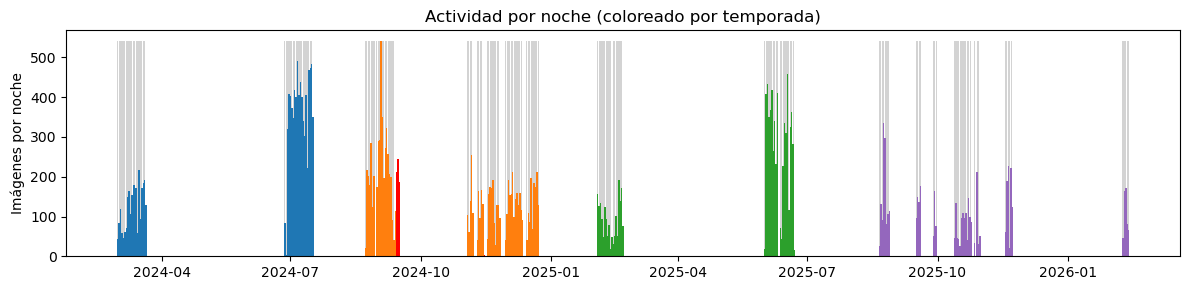

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegúrate de que la fecha sea datetime
df['date-obs'] = pd.to_datetime(df['date-obs'])

# Conteo de imágenes por noche
imgs_per_night = (
    df.groupby('date-obs')
      .size()
      .rename('n_images')
      .sort_index()
)
imgs_per_night.index = pd.to_datetime(imgs_per_night.index)

#imgs_per_night.index.to_numpy() = pd.to_datetime(imgs_per_night.index).to_numpy()
imgs_per_night = imgs_per_night.sort_index()

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons_extended = pd.concat([
    seasons_df,
    seasons_df.assign(date=seasons_df["date"] + pd.Timedelta(days=1))
]).drop_duplicates(subset=["date"], keep="first")

# Reconstruimos el dataframe desde la serie
imgs_df = pd.DataFrame({
    "date": imgs_per_night.index.to_pydatetime(),  # sacamos la fecha bien
    "n_images": imgs_per_night.to_numpy()
})

#merged = imgs_df.merge(seasons_df[['date', 'season']], on='date', how='left')

imgs_df["date"] = pd.to_datetime(imgs_df["date"]).dt.normalize()
seasons_extended["date"] = pd.to_datetime(seasons_extended["date"]).dt.normalize()

merged = imgs_df.merge(
    seasons_extended[['date', 'season']],
    on='date',
    how='left'
)

import matplotlib.pyplot as plt

season_colors = {
    "HSH-2024A-03": "tab:blue",
    "HSH-2024B-05": "tab:orange",
    "HSH-2025A-05": "tab:green",
    "HSH-2025B-03": "tab:purple",   
}
# Color gris para noches sin programa
default_color = "red"

colors = merged['season'].map(season_colors).fillna(default_color)


x = merged['date'].to_numpy()
y = merged['n_images'].to_numpy()
c = colors.to_numpy()

plt.figure(figsize=(12,3))
y_max=max(y)
for xi in x:
    if xi in seasons_df["date"].values:
        plt.bar(xi, y_max, color="lightgray")
plt.bar(x, y, width=1.0, color=c)


plt.ylabel('Imágenes por noche')
plt.title('Actividad por noche (coloreado por temporada)')
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
from datetime import datetime

rows = []

def add_range(season, start, end, program="HSH"):
    dates = pd.date_range(start, end, freq="D")
    for d in dates:
        rows.append({
            "season": season,
            "date": d,
            "program": program
        })

# =========================
# HSH-2024A-03 (40 noches)
# =========================
add_range("HSH-2024A-03", "2024-03-01", "2024-03-20")
add_range("HSH-2024A-03", "2024-06-27", "2024-07-16")

# =========================
# HSH-2024B-05 (60 noches)
# =========================
add_range("HSH-2024B-05", "2024-08-23", "2024-09-12")
add_range("HSH-2024B-05", "2024-11-02", "2024-11-06")
add_range("HSH-2024B-05", "2024-11-10", "2024-11-13")
add_range("HSH-2024B-05", "2024-11-17", "2024-11-25")
add_range("HSH-2024B-05", "2024-11-30", "2024-12-11")
add_range("HSH-2024B-05", "2024-12-15", "2024-12-23")  # incluyendo dic/23 observado

# =========================
# HSH-2025A-05 (40 noches)
# =========================
add_range("HSH-2025A-05", "2025-02-01", "2025-02-12")
add_range("HSH-2025A-05", "2025-02-14", "2025-02-20")
add_range("HSH-2025A-05", "2025-06-01", "2025-06-21")

# =========================
# HSH-2025B-03 (PLP) (56 noches)
# =========================
add_range("HSH-2025B-03", "2025-08-20", "2025-08-27", program="HSH-PLP")
add_range("HSH-2025B-03", "2025-09-15", "2025-09-30", program="HSH-PLP")
add_range("HSH-2025B-03", "2025-10-13", "2025-10-24", program="HSH-PLP")
add_range("HSH-2025B-03", "2025-10-26", "2025-10-30", program="HSH-PLP")
add_range("HSH-2025B-03", "2025-11-18", "2025-11-22", program="HSH-PLP")
add_range("HSH-2025B-03", "2025-12-17", "2025-12-21", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-01-12", "2026-01-16", program="HSH-PLP")

# =========================
# HSH-2025B-03 en 2026A
# =========================
add_range("HSH-2025B-03", "2026-02-09", "2026-02-17", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-02-24", "2026-02-28", program="HSH-PLP")

add_range("HSH-2025B-03", "2026-07-08", "2026-07-09", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-10", "2026-07-10", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-11", "2026-07-12", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-13", "2026-07-13", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-14", "2026-07-16", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-17", "2026-07-17", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-18", "2026-07-21", program="HSH-PLP")
# Crear DataFrame
seasons_df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

# Guardar CSV
seasons_df.to_csv("hsh_seasons_calendar.csv", index=False)

print(seasons_df.head())
print("Total noches:", len(seasons_df))


         season       date program
0  HSH-2024A-03 2024-03-01     HSH
1  HSH-2024A-03 2024-03-02     HSH
2  HSH-2024A-03 2024-03-03     HSH
3  HSH-2024A-03 2024-03-04     HSH
4  HSH-2024A-03 2024-03-05     HSH
Total noches: 196


In [253]:
import pandas as pd

# 1️⃣ Cargar dataset existente
seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])

# 2️⃣ Crear lista temporal para nuevos rangos
new_rows = []

def add_range(season, start, end, program="HSH"):
    dates = pd.date_range(start, end, freq="D")
    for d in dates:
        new_rows.append({
            "season": season,
            "date": d,
            "program": program
        })

# =========================
# HSH-2025B-03 en 2026A
# =========================
add_range("HSH-2025B-03", "2026-02-09", "2026-02-17", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-02-24", "2026-02-28", program="HSH-PLP")

add_range("HSH-2025B-03", "2026-07-08", "2026-07-09", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-10", "2026-07-10", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-11", "2026-07-12", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-13", "2026-07-13", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-14", "2026-07-16", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-17", "2026-07-17", program="HSH-PLP")
add_range("HSH-2025B-03", "2026-07-18", "2026-07-21", program="HSH-PLP")

# 3️⃣ Convertir nuevos rangos a DataFrame
new_df = pd.DataFrame(new_rows)

# 4️⃣ Concatenar y eliminar posibles duplicados
seasons_df = (
    pd.concat([seasons_df, new_df])
      .drop_duplicates(subset=["season", "date", "program"])
      .sort_values("date")
      .reset_index(drop=True)
)

# 5️⃣ Guardar nuevamente
seasons_df.to_csv("hsh_seasons_calendar.csv", index=False)

print("Total noches actualizado:", len(seasons_df))

Total noches actualizado: 224


In [194]:
from astropy.io import fits

filename = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250614/OGLE-2024-BLG-0034i0005.fit"

with fits.open(filename) as hdul:
    header = hdul[0].header  # header de la extensión primaria

header = dict(header)
for k, v in header.items():
    print(f"{k:>10} = {v}")


    SIMPLE = True
    BITPIX = 16
     NAXIS = 2
    NAXIS1 = 1024
    NAXIS2 = 1024
    BSCALE = 1.0
     BZERO = 32768.0
   CCDSIZE = [1:1024,1:1024]
    CCDSUM = 1 1
  PIXSIZE1 = 24.0
  PIXSIZE2 = 24.0
   ADCRATE = 
      GAIN = 2.2
   RDNOISE = 15.0
    CAMTEM = -10.0
   EXPTIME = 300.0
      DATE = 2025-06-15T00:13:51
  OBSERVAT = CASLEO
  TELESCOP = HSH
  DATE-OBS = 2025-06-15
  TIME-OBS = 03:08:44.039
        UT = 03:08:44.0
        ST = 16:06:14.8
        HA = -01:39:40.4
        RA = 17:45:55.2
       DEC = -39:07:13.1
   EQUINOX = 2025.4
   MJD-OBS = 60841.131065
        ZD = 21.5
   AIRMASS = 1.07
    RA2000 = 17:44:09.4
   DEC2000 = -39:06:39.8
   DOME-AZ = 310.3
  IMAGETYP = object
    OBJECT = OGLE-2024-BLG-0034
  INSTRUME = Direct CCD
  INSTRMOD = 
  OBSERVER = Makler
    OPTELE = 
   COMMENT = = ' '
   PROG-ID = HSH-2025A-05
  DETECTOR = STL-1001E
  PIXSCALE = 0.53
  FILTER01 = (5) I
  FILTER02 = (6) Free


### Análisis por objeto

In [269]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from datetime import timedelta
for obj in [folder for folder in os.listdir("data/objetos") if not ".csv" in folder] :
    target_folder = "data/objetos/"+obj
    photo_file = [file for file in os.listdir(target_folder) if "photometry" in file][0]
    mop_lc = pd.read_csv(target_folder+ "/"+ photo_file)
    mop_lc=mop_lc[mop_lc["Filter"].isin(["OGLE_I", "G", "i(GaiaSP)", "V(GaiaSP)"])]
    mop_lc['Timestamp'] = pd.to_datetime(mop_lc['Timestamp'])
    mop_lc['Magnitude'] = pd.to_numeric(mop_lc['Magnitude'], errors='coerce')
    mop_lc['Error'] = pd.to_numeric(mop_lc['Error'], errors='coerce')


    counts_series = (
        df[df["object"] == obj]
        .groupby(df["date-obs"].dt.date)
        .size()
        .sort_index()
    )

    dates = counts_series.index
    counts = counts_series.values
    if len(counts)==0:
        print(f"No images for object {obj}")
        continue


    fig, ax = plt.subplots(figsize=(10,4))

    norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
    cmap = plt.get_cmap("viridis_r")

    for date, value in zip(dates, counts):
        ax.axvspan(
            date,
            date + timedelta(days=1),
            color=cmap(norm(value)),
            alpha=0.6
        )
    filters = mop_lc["Filter"].unique()
    for filt in filters:
        lc_filt = mop_lc[mop_lc["Filter"]==filt]
        ax.plot(lc_filt["Timestamp"], lc_filt["Magnitude"], "o", ms=2, label = filt)
    #print(mop_lc["Filter"].value_counts())

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Number of images")

    ax.set_xlim(df["date-obs"].min() - timedelta(days=60),
                df["date-obs"].max() + timedelta(days=5))
    #ax.set_ylim(0, 1)

    ax.set_title(f"{obj} light curve (Total images = {sum(counts)})")
    

    #print(mop_lc["Filter"].value_counts())
    plt.gca().invert_yaxis()
    plt.legend()
    # Fecha en formato AAAAMMDD (uso la fecha mínima de observación del objeto)
    date_str = df[df["object"] == obj]["date-obs"].max().strftime("%Y%m%d")

    filename = f"{obj}_lc_{date_str}.png"
    filepath = os.path.join("plots", filename)

    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)
 
#plt.legend(loc=(1.01,0), ncols=4)

No images for object OGLE-2025-DG-0010
No images for object OGLE-2024-BLG-0675
No images for object OGLE-2024-DG-0006
No images for object OGLE-2025-BLG-0303
No images for object OGLE-2025-BLG-0901
No images for object OGLE-2025-BLG-0075
No images for object OGLE-2025-DG-0019
No images for object OGLE-2024-GD-0009
No images for object OGLE-2025-BLG-1457


In [272]:
import pandas as pd

# -----------------------------
# 1️⃣ Normalizar fecha en df
# -----------------------------
df["night"] = pd.to_datetime(df["night"]).dt.normalize()

# -----------------------------
# 2️⃣ Cargar calendario de temporadas
# -----------------------------
seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons_df["date"] = seasons_df["date"].dt.normalize()

# -----------------------------
# 3️⃣ Merge para asignar season a cada imagen
# -----------------------------
df_season = df.merge(
    seasons_df[["date", "season"]],
    left_on="night",
    right_on="date",
    how="left"
)

# -----------------------------
# 4️⃣ Tabla: número de imágenes por objeto por temporada
# -----------------------------
table_images = (
    df_season
    .groupby(["season", "object"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print(table_images)

object        ASASSN-24fs  Gaia23cnu  Gaia23dpn  Gaia24bsi  Gaia24bsj  \
season                                                                  
HSH-2024A-03            0        168         28          0          0   
HSH-2024B-05          112          0          0       1333       1157   
HSH-2025A-05            0          0          0          0          0   
HSH-2025B-03           40          0          0        312        263   

object        Gaia24ddl  NO_OBJECT  OGLE-2023-BLG-0723  OGLE-2023-GD-0011  \
season                                                                      
HSH-2024A-03          0        255                   1                389   
HSH-2024B-05          0         26                   0                  0   
HSH-2025A-05        233         73                   0                  0   
HSH-2025B-03         23         73                   0                  0   

object        OGLE-2024-BLG-0002  ...  OGLE-2024-GD-0014  OGLE-2025-BLG-0245  \
season            

In [273]:
import pandas as pd

# -----------------------------
# 1️⃣ Normalizar fechas
# -----------------------------
df["night"] = pd.to_datetime(df["night"]).dt.normalize()

seasons_df = pd.read_csv("hsh_seasons_calendar.csv", parse_dates=["date"])
seasons_df["date"] = seasons_df["date"].dt.normalize()

# -----------------------------
# 2️⃣ Merge para asignar temporada
# -----------------------------
df_season = df.merge(
    seasons_df[["date", "season"]],
    left_on="night",
    right_on="date",
    how="left"
)

# Opcional: quitar imágenes fuera de temporada
df_season = df_season.dropna(subset=["season"])

# -----------------------------
# 3️⃣ Tabla doble entrada
# -----------------------------
table = pd.crosstab(
    df_season["object"],
    df_season["season"]
)

# -----------------------------
# 4️⃣ Agregar totales
# -----------------------------

# Total por objeto (fila)
table["TOTAL"] = table.sum(axis=1)

# Total por temporada (fila final)
total_row = table.sum(axis=0)
total_row.name = "TOTAL"

table = pd.concat([table, total_row.to_frame().T])

print(table)

season              HSH-2024A-03  HSH-2024B-05  HSH-2025A-05  HSH-2025B-03  \
ASASSN-24fs                    0           112             0            40   
Gaia23cnu                    168             0             0             0   
Gaia23dpn                     28             0             0             0   
Gaia24bsi                      0          1333             0           312   
Gaia24bsj                      0          1157             0           263   
Gaia24ddl                      0             0           233            23   
NO_OBJECT                    255            26            73            73   
OGLE-2023-BLG-0723             1             0             0             0   
OGLE-2023-GD-0011            389             0             0             0   
OGLE-2024-BLG-0002            89             0             0             0   
OGLE-2024-BLG-0009            59             0             0             0   
OGLE-2024-BLG-0010           159             0             0    

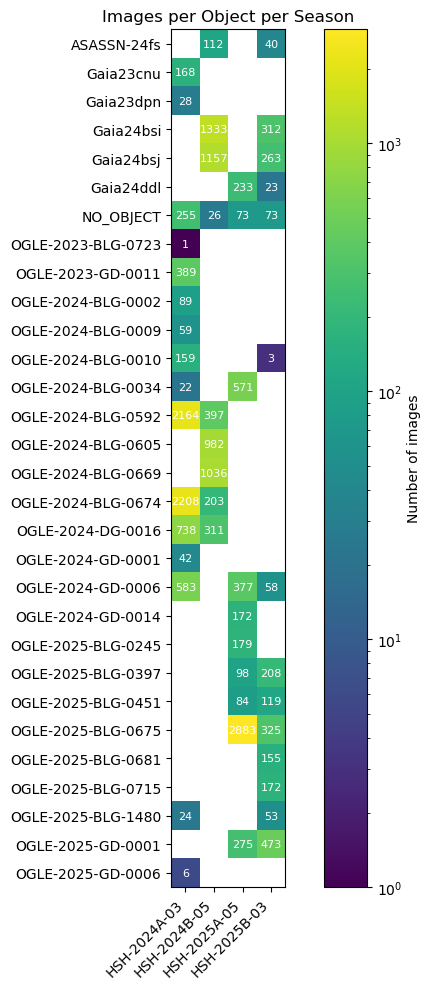

In [282]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Separar totales
heatmap_data = table.drop(index="TOTAL").drop(columns="TOTAL")

fig, ax = plt.subplots(figsize=(8,10))

#im = ax.imshow(heatmap_data.values, cmap="viridis")
norm = mcolors.LogNorm(
    vmin=max(1, heatmap_data.values.min()),
    vmax=heatmap_data.values.max()
)

im = ax.imshow(heatmap_data.values, cmap="viridis", norm=norm)

# Etiquetas
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_data.index)

# Anotar valores
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j, i,
            heatmap_data.iloc[i, j],
            ha="center", va="center",
            fontsize=8,
            color="white"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of images")

ax.set_title("Images per Object per Season")
plt.tight_layout()
plt.show()

In [300]:
table

season,HSH-2024A-03,HSH-2024B-05,HSH-2025A-05,HSH-2025B-03,TOTAL
ASASSN-24fs,0,112,0,40,152
Gaia23cnu,168,0,0,0,168
Gaia23dpn,28,0,0,0,28
Gaia24bsi,0,1333,0,312,1645
Gaia24bsj,0,1157,0,263,1420
Gaia24ddl,0,0,233,23,256
NO_OBJECT,255,26,73,73,427
OGLE-2023-BLG-0723,1,0,0,0,1
OGLE-2023-GD-0011,389,0,0,0,389
OGLE-2024-BLG-0002,89,0,0,0,89


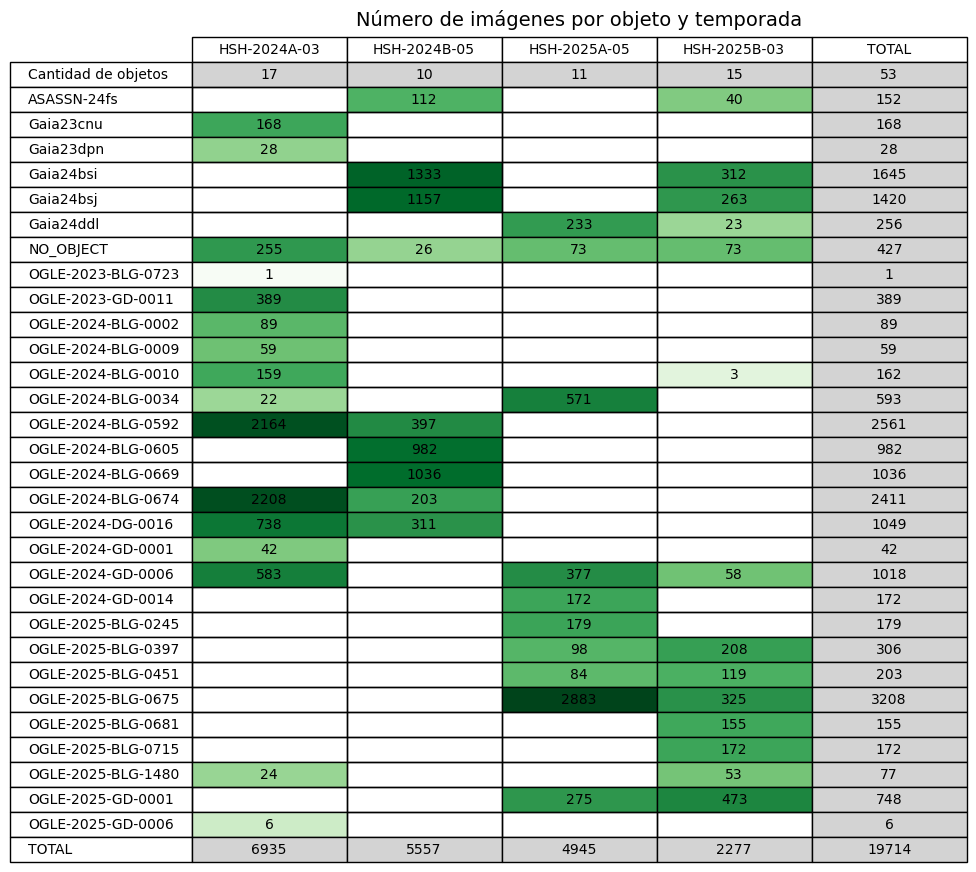

In [312]:
import pandas as pd

# 1️⃣ Calcular cantidad de objetos por temporada
# Solo consideramos las columnas de temporadas, no TOTAL
season_cols = [c for c in table.columns if c != "TOTAL"]

obj_count_row = (table[season_cols] > 0).sum(axis=0)  # número de objetos con al menos 1 imagen por temporada
obj_count_row["TOTAL"] = sum(obj_count_row)  # podemos dejar vacío o poner el total general de objetos

# Convertir en DataFrame de 1 fila con mismo índice
obj_count_row_df = pd.DataFrame([obj_count_row], index=["Cantidad de objetos"])

# 2️⃣ Concatenar fila arriba de la tabla original
table_with_count = pd.concat([obj_count_row_df, table])



# Asumimos que 'table' es la tabla final con TOTAl fila y columna
data = table_with_count.values
rows = table_with_count.index.astype(str).tolist()
cols = table_with_count.columns.astype(str).tolist()

fig, ax = plt.subplots(figsize=(10, max(4, len(rows)*0.25+1)))

ax.axis('off')  # ocultar ejes




from matplotlib.colors import LogNorm

# Evitar ceros porque log(0) no existe
image_data = table_with_count.drop("TOTAL", axis=1).drop("TOTAL", axis=0)
image_data_nonzero = image_data.replace(0, np.nan)  # ceros se pintarán blancos

norm = LogNorm(vmin=image_data_nonzero.min().min(), vmax=image_data_nonzero.max().max())
cmap = plt.get_cmap("Greens")

# Dibujar celdas coloreadas
cell_text = []
cell_colors = []
for r_idx, row in enumerate(data):
    row_text = []
    row_colors = []
    for c_idx, val in enumerate(row):
        if str(val)!="0":
            row_text.append(str(val))
        else:
            row_text.append("")
        # Colorear solo celdas que no sean totales
        if (rows[r_idx] != "TOTAL") and (cols[c_idx] != "TOTAL") and ((rows[r_idx] != "Cantidad de objetos") ):
            color = cmap(norm(val))
        else:
            color = "lightgray"  # gris claro para totales
        row_colors.append(color)
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Crear tabla
the_table = ax.table(
    cellText=cell_text,
    rowLabels=rows,
    colLabels=cols,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center'
)

the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1, 1.5)  # ancho x alto de las celdas

plt.title("Número de imágenes por objeto y temporada", fontsize=14, y=1.1)
plt.show()

In [188]:
for i in df.columns:
    print(i)

equinox
a_1_0
bp_order
a_0_2
latpole
bp_0_1
st
naxis
crpix2
ap_0_0
a_2_0
exptime
dec2000
prog-id
ap_2_0
crpix1
dec
ctype2
a_1_1
zd
filter02
history
ccdsize
a_0_1
_quinox
bp_1_0
a_0_0
optele
trk_frq
ctype1
ut
cunit1
dome-az
lonpole
naxis1
bp_2_0
pixscale
rdnoise
object
b_1_1
a_order
filter01
ap_1_0
filter
ap_0_1
observer
b_order
ra
wcsaxes
time-obs
cd1_1
cd1_2
cd2_1
night
crval1
cd2_2
imagetyp
observat
ap_1_1
b_0_1
telescop
dec_prld
date-obs
ha_prld
pixsize1
crval2
ha
filter1
bzero
b_2_0
ra2000
bp_0_0
naxis2
pixsize2
bscale
instrmod
adcrate
file
ccdsum
comment
date
mjd-obs
gain
simple
ap_0_2
bitpix
instrume
imageh
imagew
airmass
b_0_0
ap_order
b_1_0
cunit2
bp_0_2
bp_1_1
b_0_2
detector
camtem
wheel
wheel_aux
orig_obj
nearest_obj
sep_arcsec
name_match
close_match
